In [97]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [98]:
# LIB: Base

task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

device_key = "Device"
device_proxy = "P"
device_controller = "C"
devices = [device_controller, device_proxy]

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"
scalings = [scaling_none, scaling_subtle, scaling_pronounced]

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

def get_confidence_interval(values):
    return 1.96 * np.std(values) / np.sqrt(len(values))

In [99]:
# LIB: Data

cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    "39_JeOb",
    "40_HeSe",
    "41_AnOb",
    "42_StSp",
    ]

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_res_key = 'GSR Resistance CAL'
gsr_con_key = 'GSR Conductance CAL'
imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_res_key, gsr_con_key]

baseline_ms = 30_000

extrema_quantile = 0.25

def remove_timeseries_outliers(df, key):
    df = df.dropna(subset = key)
    return df[np.abs(stats.zscore(df[key])) < 3] if key != hr_key else df

def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    if e == cube:
        return df[unity_unix_key].min()
    else:
        first_load = df[(df["collision_or_load_count"] == 1)]
        return first_load[unity_unix_key].min()

def task_end(df, e):
    if e == cube:
        return df[unity_unix_key].max()
    else:
        final_load = df[(df["collision_or_load_count"] == 20)]
        final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

        return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    imot_pre_task = trim_df(imot_synced, task_start_ts - baseline_ms, task_start_ts)

    min_hr = remove_timeseries_outliers(imot_pre_task, hr_key)[hr_key].quantile(extrema_quantile)
    max_gsr_res = remove_timeseries_outliers(imot_pre_task, gsr_res_key)[gsr_res_key].quantile(1-extrema_quantile)
    min_gsr_con = remove_timeseries_outliers(imot_pre_task, gsr_con_key)[gsr_con_key].quantile(extrema_quantile)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts,
        "min_hr": min_hr,
        "max_gsr_res": max_gsr_res,
        "min_gsr_con": min_gsr_con
    }

def get_experiment(p, e):

    condition_data = list(map(lambda x: get_condition(p, e, x), conditions))

    min_hr = np.min(list(map(lambda x: x["min_hr"], condition_data)))
    max_gsr_res = np.max(list(map(lambda x: x["max_gsr_res"], condition_data)))
    min_gsr_con = np.min(list(map(lambda x: x["min_gsr_con"], condition_data)))

    return {
            c_0: condition_data[0],
            c_1: condition_data[1],
            c_2: condition_data[2],
            p_0: condition_data[3],
            p_1: condition_data[4],
            p_2: condition_data[5],
            "min_hr": min_hr,
            "max_gsr_res": max_gsr_res,
            "min_gsr_con": min_gsr_con
    }
def get_participant(p):
    return {
        cube: get_experiment(p, cube),
        shovel: get_experiment(p, shovel),
        subject_key: p
    }

In [100]:
# LIB: Significance Testing

significance_key = "Significance"
aov_key = "aov"
pairwise_key = "pairwise"
eff_size_key = "ng2"

def get_significant_entries(df):
    return df[df[significance_key] == "✅"]

def get_semi_significant_entries(df):
    return df[df[significance_key] != "❌"]

def rm_anova(df, value_key, two_way):
    within = [device_key, scaling_key] if two_way else condition_key

    aov = pg.rm_anova(
        dv=value_key,
        within=within,
        subject=subject_key,
        data=df,
        detailed=True
    )

    p_unc = "p-unc"
    p_corr = "p-GG-corr"
    aov[significance_key] = aov.apply(lambda x:
        "✅" if
            (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    display(aov)

    pairwise = pg.pairwise_tests(
    dv=value_key,
    within=within,
    subject=subject_key,
    data=df,
    padjust='holm'
    )

    p_unc = "p-unc"
    p_corr = "p-corr"
    pairwise[significance_key] = pairwise.apply(lambda x:
        "✅" if
            (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    significant_sources = get_significant_entries(aov).get("Source").tolist()
    valid_pairwise = pairwise[pairwise["Contrast"].isin(significant_sources)]

    if(valid_pairwise.shape[0] > 0):
        display(valid_pairwise)

    return {
        aov_key: aov,
        pairwise_key: valid_pairwise
    }

#Adapted from https://stackoverflow.com/questions/11517986/indicating-the-statistically-significant-difference-in-bar-graph
def barplot_annotate_brackets(ax, num1, num2, data, x, y, offset, height, addtext='', color="black", fs=None, maxasterix=3):
    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = x[num1], y[num1]
    rx, ry = x[num2], y[num2]

    y = max(ly, ry) + offset

    barx = [lx, lx, rx, rx]
    bary = [y, y+height, y+height, y]
    mid = ((lx+rx)/2, y+height)

    ax.plot(barx, bary, c=color)

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    if addtext != "":
        text = text + " (" + addtext + ")"

    ax.text(*mid, text, color=color, **kwargs)

condition_dict = {'C0': 0, 'C1': 1, 'C2': 2, 'P0': 3, 'P1': 4, 'P2': 5}

def plot_significance_brackets(ax, scale, barheights, brackets):
    n_bars = np.arange(len(conditions))

    offset_step = (scale[1] - scale[0]) / 5
    bracket_height = offset_step * 0.25
    fixed_heights =  [np.max(barheights) + bracket_height*2] * len(conditions)

    current_offset = 0

    for bracket in brackets:
        barplot_annotate_brackets(ax, bracket[0], bracket[1], bracket[2], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
        current_offset += offset_step

    # Set axis limits to provided scale or max bracket height if higher
    ax.set_ylim([scale[0], np.max([fixed_heights[0]+current_offset, scale[1]])])

def plot_values(axs, idx, values, labels, scale, ylabel, title, brackets, clrs=colors):
    means = list(map(lambda x: np.mean(x), values))
    conf = list(map(get_confidence_interval, values))

    axs_first = axs[0, idx]
    axs_second = axs[1, idx]
    axs_third = axs[2, idx]

    axs_first.bar(labels, means, color=clrs)
    axs_first.errorbar(labels, means, yerr= conf, fmt='none', capsize=6, color="black")
    axs_first.set_title(title)

    barheights = []
    for i in range(len(labels)):
        barheights.append(means[i] + conf[i])

    plot_significance_brackets(axs_first, scale if scale is not None else axs_first.get_ylim(), barheights, brackets)

    n_bars = np.arange(len(labels))

    axs_second.violinplot(values, showmeans=True)
    #axs_second.set_title(title + ' Violin (+Mean)')
    #axs_second.set_xticks([])
    axs_second.set_xticks([y + 1 for y in n_bars], labels=labels)


    axs_third.boxplot(values, tick_labels=labels)
    #axs_third.set_title(title + ' Boxplot')
    #axs_third.set_xticks([])

    if scale is not None:
        axs_first.set_yticks(range(scale[0], scale[1]+1))
        axs_second.set_ylim([scale[0]-0.5, scale[1]+0.5])
        axs_third.set_ylim([scale[0]-0.5, scale[1]+0.5])

    if ylabel is not None and idx == 0:
        axs_first.set_ylabel(ylabel)
        axs_second.set_ylabel(ylabel)
        axs_third.set_ylabel(ylabel)

def plot_experiment(df, e, key, title, scale, ylabel, two_way_tests, one_way_tests):
    fig, axs = plt.subplots(3, 3, figsize=(20, 10), width_ratios=[1, 1, 2])
    fig.suptitle('[' + e + '] ' + title)

    device_values = list(map(lambda x: df[df[device_key] == x][key], devices))
    device_brackets = []
    device_test = two_way_tests.loc[(two_way_tests['Contrast'] == device_key)]
    for index, row in device_test.iterrows():
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        device_brackets.append([0,1,p_value])
    plot_values(axs, 0, device_values, devices, scale, ylabel, "Device", brackets=device_brackets, clrs=["tab:blue", "tab:red"])

    scaling_values = list(map(lambda x: df[df[scaling_key] == x][key], scalings))
    scaling_brackets = []
    scaling_test = two_way_tests.loc[(two_way_tests['Contrast'] == scaling_key)]
    for index, row in scaling_test.iterrows():
        a = int(row["A"])
        b = int(row["B"])
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        scaling_brackets.append([a,b,p_value])
    plot_values(axs, 1, scaling_values, scalings, scale, ylabel, "Scaling", brackets=scaling_brackets)

    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    condition_brackets = []
    for index, row in one_way_tests.iterrows():
        a = condition_dict[row["A"]]
        b = condition_dict[row["B"]]
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        condition_brackets.append([a,b,p_value])
    plot_values(axs, 2, condition_values, conditions, scale, ylabel, "Condition", brackets=condition_brackets)

    fig.tight_layout()
    plt.show()

cube_aovs = []
shovel_aovs = []
aovs_dv_key = "key"
two_way_key = "two_way"
one_way_key = "one_way"

def try_add_aov_entry(new_entry, e):
    if e == cube and not any(x[aovs_dv_key] == new_entry[aovs_dv_key] for x in cube_aovs):
        cube_aovs.append(new_entry)
    elif e == shovel and not any(x[aovs_dv_key] == new_entry[aovs_dv_key] for x in shovel_aovs):
        shovel_aovs.append(new_entry)

def report_experiment_core(df, e, key, title, scale = None, ylabel = None):
    print('\033[1m' + "------ " + "["+e+"] " + title + ": Two-Way RM ANOVA"  + " ------")
    two_way_result = rm_anova(df, key, two_way=True)
    print('\033[1m' + "------ " + "["+e+"] " + title + ": One-Way RM ANOVA"  + " ------")
    one_way_result = rm_anova(df, key, two_way=False)

    aov_entry = {
        aovs_dv_key: title,
        two_way_key: two_way_result[aov_key],
        one_way_key: one_way_result[aov_key]
    }
    try_add_aov_entry(aov_entry, e)

    two_way_sig_pairwise = get_significant_entries(two_way_result[pairwise_key])
    one_way_sig_pairwise = get_significant_entries(one_way_result[pairwise_key])

    plot_experiment(df, e, key, title, scale, ylabel, two_way_sig_pairwise, one_way_sig_pairwise)

def get_aov_eff_sizes(entry):
    eff_sizes = []

    one_way = entry[one_way_key]
    row = one_way.iloc[0] #Second row is error entry
    if row[significance_key] == "✅":
        eff_sizes.append(row[eff_size_key])
    else:
        eff_sizes.append(0)

    two_way = entry[two_way_key]
    for index, row in two_way.iterrows():
        if row[significance_key] == "✅":
            eff_sizes.append(row[eff_size_key])
        else:
            eff_sizes.append(0)

    return eff_sizes

def show_eff_size_comparison(title):
    columns = [condition_key, device_key, scaling_key, device_x_scaling_key]
    eff_size_colors = ["tab:green", "tab:blue", "tab:orange", "tab:red"]

    cube_aov_index = list(map(lambda x: x[aovs_dv_key], cube_aovs))
    cube_aov_values = list(map(lambda x: get_aov_eff_sizes(x), cube_aovs))
    cube_df = pd.DataFrame(cube_aov_values, columns=columns, index = cube_aov_index)
    cube_df.plot(kind='barh', color=eff_size_colors)
    plt.title("[Cube] " + title +  " effect size comparison")
    plt.xlabel("Effect size [" + eff_size_key + "]")
    plt.ylabel("Dependent variable")
    plt.xlim([0,0.65])
    plt.gca().invert_yaxis()
    plt.show()

    shovel_aov_index = list(map(lambda x: x[aovs_dv_key], shovel_aovs))
    shovel_aov_values = list(map(lambda x: get_aov_eff_sizes(x), shovel_aovs))
    shovel_df = pd.DataFrame(shovel_aov_values, columns=columns, index = shovel_aov_index)
    shovel_df.plot(kind='barh', color=eff_size_colors)
    plt.title("[Shovel] " + title +  " effect size comparison")
    plt.xlabel("Effect size [" + eff_size_key + "]")
    plt.ylabel("Dependent variable")
    plt.xlim([0,0.65])
    plt.gca().invert_yaxis()
    plt.show()

In [101]:
# Notebook Defs

def pre_post_delta(p, key):
    end = p[end_ts]

    end_df = trim_df(p[imot], min_ts = end, max_ts = end + baseline_ms)
    end_df = remove_timeseries_outliers(end_df, key)

    baseline = p["min_hr"] if key == hr_key else (p["max_gsr_res"] if key == gsr_res_key else (p["min_gsr_con"] if key == gsr_con_key else 0))

    return end_df[key].quantile(1-extrema_quantile) - baseline

def normalized_auc(p, key):
    start = p[start_ts]
    end = p[end_ts]
    duration = start-end

    task_df = trim_df(p[imot], min_ts = start, max_ts = end)
    task_df = remove_timeseries_outliers(task_df, key)

    baseline = p["min_hr"] if key == hr_key else (p["max_gsr_res"] if key == gsr_res_key else (p["min_gsr_con"] if key == gsr_con_key else 0))

    return metrics.auc(task_df[unified_delta_key].apply(lambda x: x / duration), task_df[key].apply(lambda x: x - baseline))

tuple_value_key = "v"
tuple_subject_key = "p"

def find_outliers(tuples, m=3):
    values = list(map(lambda x: x[tuple_value_key], tuples))
    mean = np.mean(values)
    std = np.std(values)

    outliers = []
    for i in tuples:
        value = i[tuple_value_key]
        if np.abs(value - mean) > m * std:
            outliers.append(i)

    return outliers

def agg_values(data, single_func, e, c):
    participant_values = list(map(lambda x: {tuple_value_key: single_func(x[e][c]), tuple_subject_key: x[subject_key]}, data))
    return participant_values

def get_condition_values(data, single_func, e, remove_outliers):
    complete_values =  []
    outliers_set = set([])

    for c in conditions:
        condition_values = agg_values(data, single_func, e, c)
        complete_values.append(condition_values)

        if remove_outliers:
            cond_outliers = find_outliers(condition_values)
            for i in cond_outliers:
                print("[" + e + "] " + c + " subject " + i[tuple_subject_key] + " is outlier")
                outliers_set.add(i[tuple_subject_key])

    if remove_outliers:
        for outlier in outliers_set:
            print("[" + e + "] dropping subject " + outlier)

        #Filter out outliers from ALL conditions afterwards
        filtered_values = []
        for condition_values in complete_values:
            filtered_condition_values = list(filter(lambda x: x[tuple_subject_key] not in outliers_set, condition_values))
            filtered_values.append(filtered_condition_values)

        return filtered_values

    else:
        return complete_values

def report_exeriment(data, func, e, title, ylabel, remove_outliers = True):
    condition_values = get_condition_values(data, func, e, remove_outliers)

    #Construct DF matching LIB format
    value_key = 'target_var'
    data =  {subject_key: [], device_key: [], scaling_key: [], value_key: [], condition_key: []}
    df = pd.DataFrame(data)

    for i in range(len(conditions)):
        n_values = len(condition_values[i])
        device = [conditions[i][0]] * n_values # Device is always the same for condition
        scaling = [conditions[i][1:]] * n_values # Scaling is always the same for condition
        cond = [conditions[i]] * n_values # Condition is always the same for condition

        values = list(map(lambda x: x[tuple_value_key], condition_values[i]))
        subjects = list(map(lambda x: x[tuple_subject_key], condition_values[i]))

        condition_data = {subject_key: subjects, device_key: device, scaling_key: scaling, value_key: values, condition_key: cond}
        condition_rows = pd.DataFrame(condition_data)
        df = pd.concat([df, condition_rows], ignore_index=True)

    report_experiment_core(df, e, value_key, title, scale=None, ylabel=ylabel)

In [102]:
data = list(map(lambda x: get_participant(x), cohort))

print(data[0][subject_key])
print(data[len(data)-1][subject_key])
data[0][shovel][c_0][unity].head(3)

1_AlDe
42_StSp


,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,hmd_z,ee_x,ee_y,ee_z,shovel_loaded_state,cube_max_target_reached,grab_count,collision_or_load_count,unix_ms,delta_ms
0,6/17/2025 12:47:46 PM,1750157266336,Right,0.013479,0.082617,0.009835,-0.026263,0.161040,0.275415,0.013534,...,0.109002,-0.000339,0.069995,0.740010,False,0,1,0,1750157266336,-7097
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,0.108624,-0.109571,0.213849,0.729117,False,0,1,0,1750157266350,-7083
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,0.107817,-0.109463,0.209042,0.729566,False,0,1,0,1750157266379,-7054


[Cube] C2 subject 22_ClSt is outlier
[Cube] dropping subject 22_ClSt
------ [Cube] Heart Rate Delta: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,357.969766,1,40,357.969766,10.532887,0.002373,0.002373,0.025064,1.000000,✅
1,Scaling,23.049289,2,80,11.524644,0.239003,0.787973,0.776204,0.001653,0.947487,❌
2,Device * Scaling,106.119411,2,80,53.059705,1.153392,0.320756,0.316694,0.007564,0.889121,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.245441,40.0,two-sided,0.002373,NaN,NaN,14.095,-0.463298,✅


------ [Cube] Heart Rate Delta: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,ng2,eps,Significance
0,Condition,487.138465,5,97.427693,2.190059,0.056777,0.033802,0.824861,🟨
1,Error,8897.267785,200,44.486339,NaN,NaN,NaN,NaN,❌


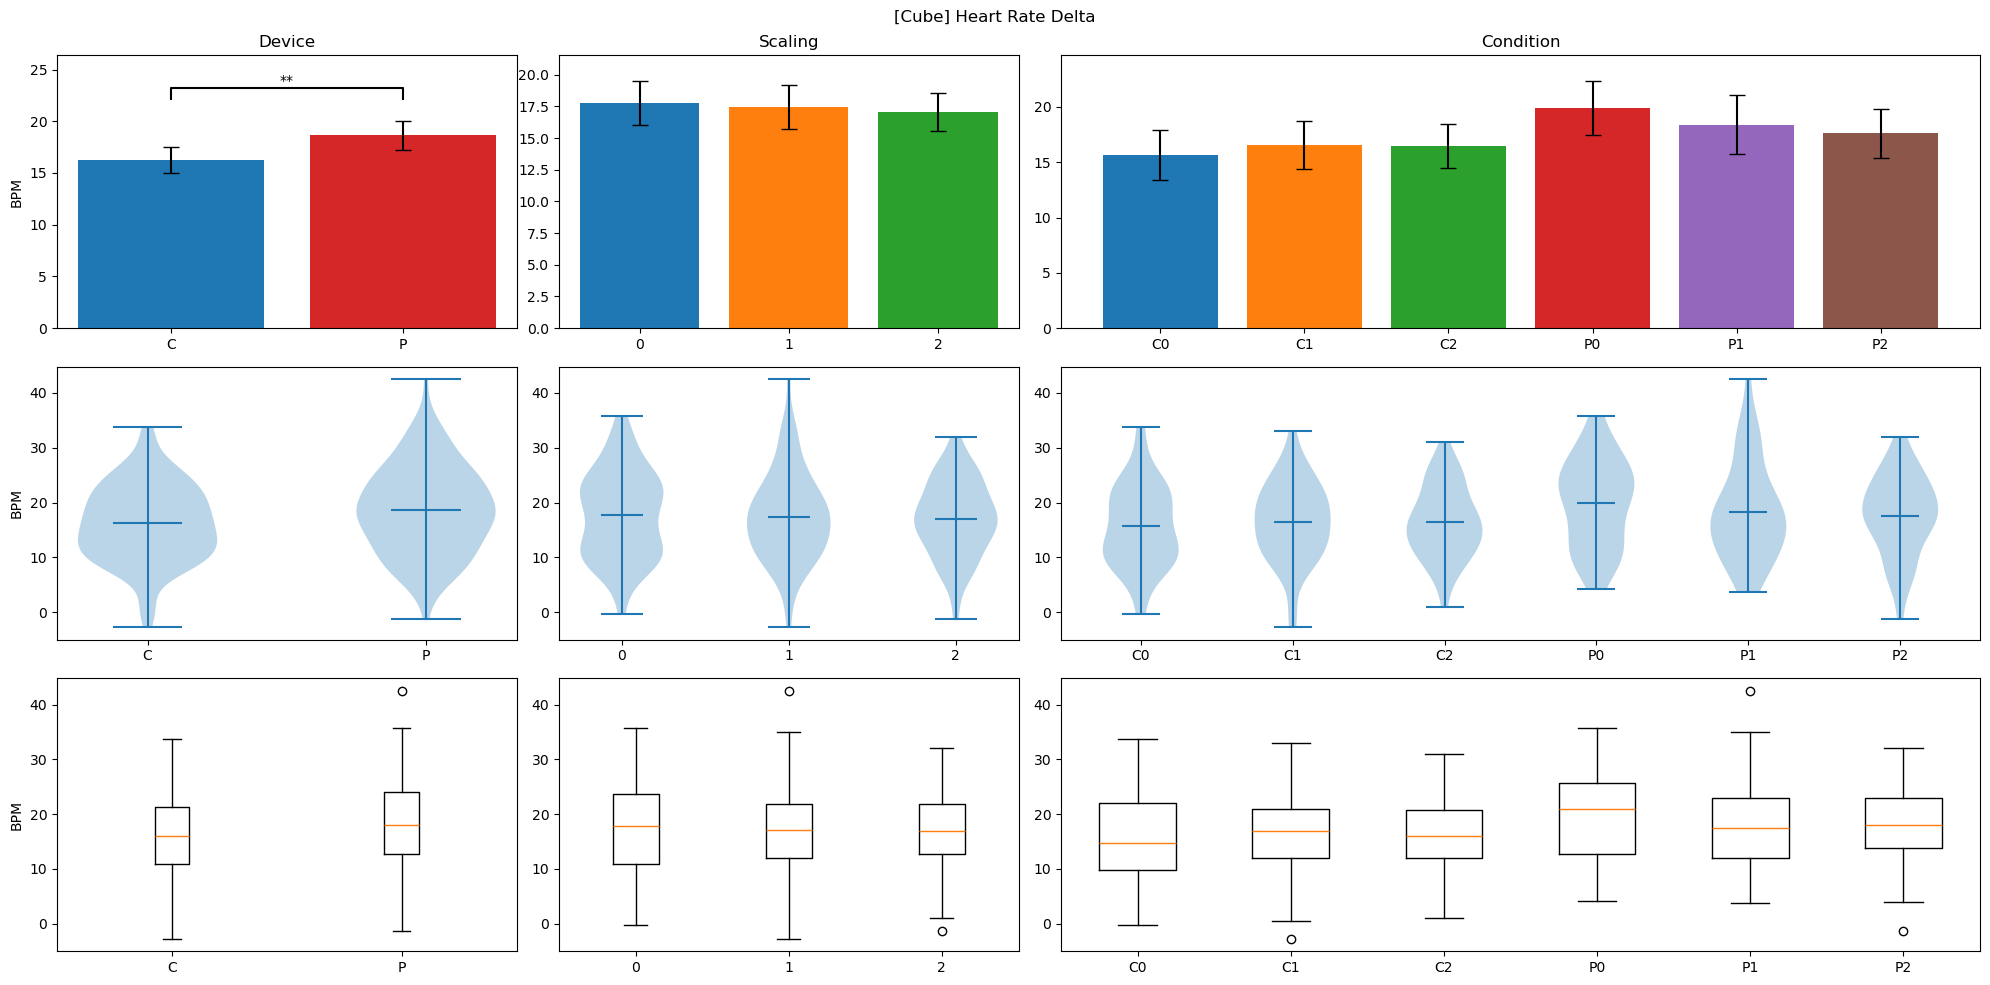

------ [Shovel] Heart Rate Delta: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,412.723214,1,41,412.723214,9.478558,0.003700,0.003700,0.029829,1.000000,✅
1,Scaling,195.031250,2,82,97.515625,3.216646,0.045198,0.045624,0.014321,0.991998,✅
2,Device * Scaling,64.209821,2,82,32.104911,1.283219,0.282650,0.282311,0.004761,0.971806,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.078727,41.0,two-sided,0.003700,NaN,NaN,9.471,-0.421959,✅
1,Scaling,-,0,1,True,True,-0.315974,41.0,two-sided,0.753626,0.753626,holm,0.175,-0.044299,❌
2,Scaling,-,0,2,True,True,1.948180,41.0,two-sided,0.058261,0.116522,holm,0.928,0.252023,❌
3,Scaling,-,1,2,True,True,2.349858,41.0,two-sided,0.023676,0.071028,holm,1.935,0.320834,🟨


------ [Shovel] Heart Rate Delta: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,ng2,eps,Significance
0,Condition,671.964286,5,134.392857,4.357384,0.000863,0.047672,0.911681,✅
1,Error,6322.723214,205,30.842552,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.222576,41.0,two-sided,0.824971,1.000000,holm,0.171,0.037928,❌
1,Condition,C0,C2,True,True,0.943575,41.0,two-sided,0.350914,1.000000,holm,0.253,0.124452,❌
2,Condition,C0,P0,True,True,-2.461920,41.0,two-sided,0.018114,0.181139,holm,2.42,-0.359845,❌
3,Condition,C0,P1,True,True,-2.974556,41.0,two-sided,0.004900,0.063695,holm,7.414,-0.463470,🟨
4,Condition,C0,P2,True,True,-0.190916,41.0,two-sided,0.849533,1.000000,holm,0.17,-0.030741,❌
5,Condition,C1,C2,True,True,0.590608,41.0,two-sided,0.558025,1.000000,holm,0.197,0.102972,❌
6,Condition,C1,P0,True,True,-2.307376,41.0,two-sided,0.026158,0.235421,holm,1.781,-0.457007,❌
7,Condition,C1,P1,True,True,-3.009621,41.0,two-sided,0.004460,0.062440,holm,8.047,-0.575684,🟨
8,Condition,C1,P2,True,True,-0.394665,41.0,two-sided,0.695136,1.000000,holm,0.18,-0.071612,❌
9,Condition,C2,P0,True,True,-2.864081,41.0,two-sided,0.006565,0.072210,holm,5.754,-0.482949,🟨


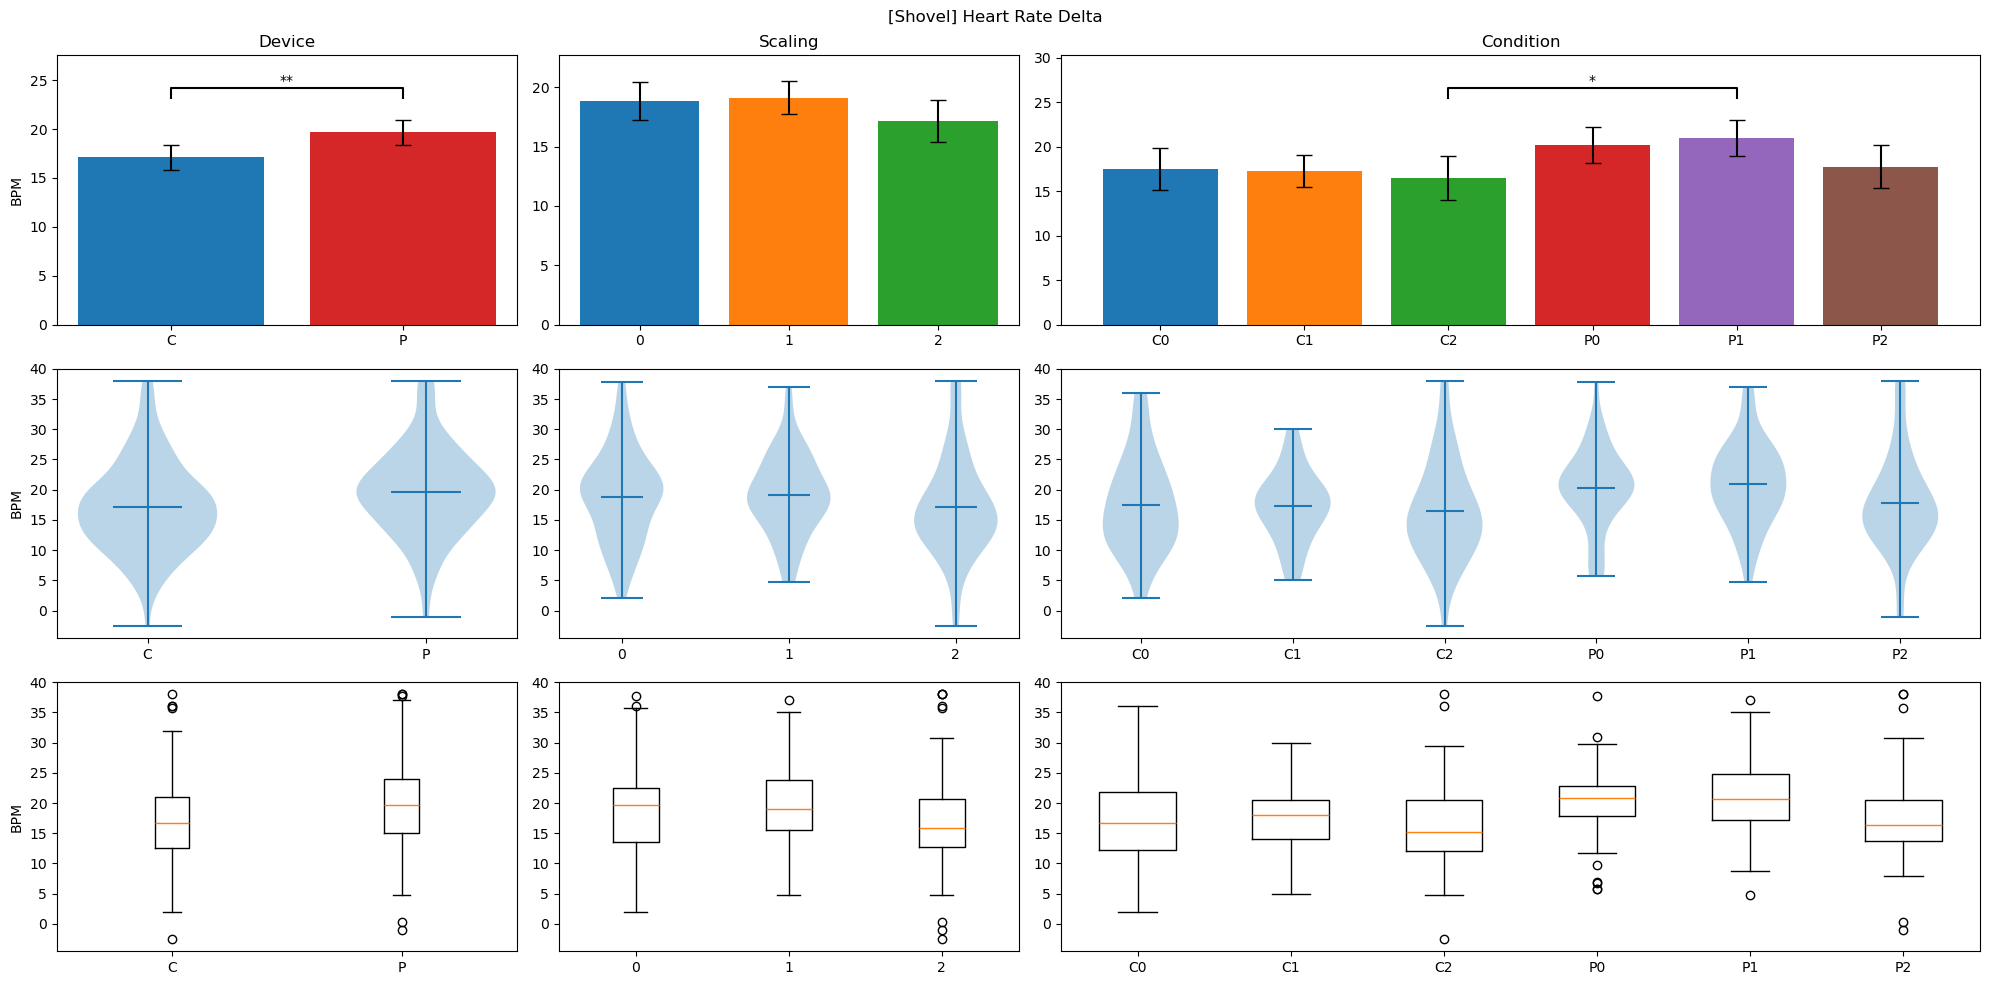

In [103]:
def hr_delta(p):
    return pre_post_delta(p, hr_key)

title = 'Heart Rate Delta'
ylabel = 'BPM'
report_exeriment(data, hr_delta, cube, title, ylabel)
report_exeriment(data, hr_delta, shovel, title, ylabel)

[Cube] C0 subject 31_GiDe is outlier
[Cube] P0 subject 12_ViDi is outlier
[Cube] dropping subject 31_GiDe
[Cube] dropping subject 12_ViDi
------ [Cube] Heart Rate AUC: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.663795,1,39,5.663795,0.161184,0.690260,0.690260,0.000796,1.000000,❌
1,Scaling,102.943978,2,78,51.471989,2.425814,0.095049,0.098457,0.014272,0.944075,🟨
2,Device * Scaling,44.484316,2,78,22.242158,0.809129,0.448947,0.436215,0.006218,0.886688,❌


------ [Cube] Heart Rate AUC: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,ng2,eps,Significance
0,Condition,153.092090,5,30.618418,1.154946,0.332925,0.021078,0.864946,❌
1,Error,5169.586928,195,26.510702,NaN,NaN,NaN,NaN,❌


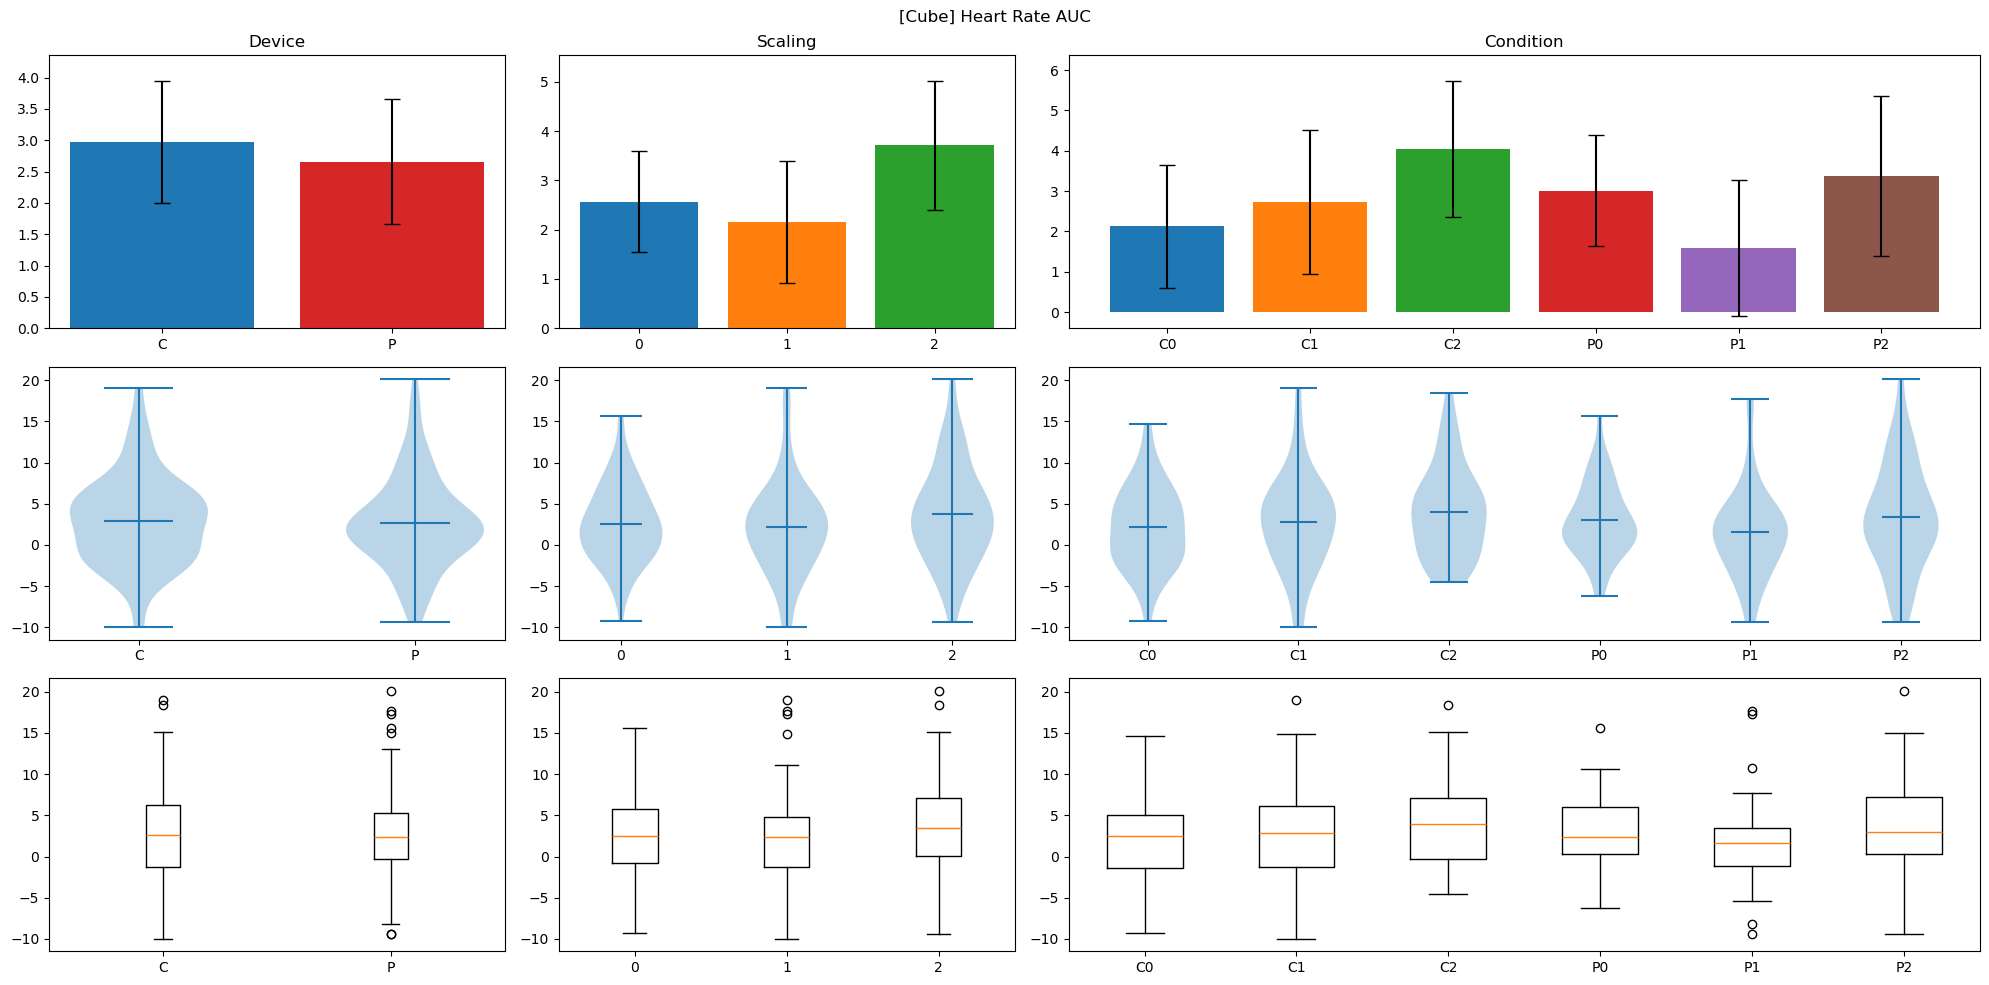

[Shovel] P0 subject 42_StSp is outlier
[Shovel] dropping subject 42_StSp
------ [Shovel] Heart Rate AUC: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,195.572900,1,40,195.572900,5.626348,0.022592,0.022592,0.025345,1.000000,✅
1,Scaling,69.328457,2,80,34.664229,1.549963,0.218562,0.219276,0.009134,0.966164,❌
2,Device * Scaling,77.810616,2,80,38.905308,2.101950,0.128917,0.131691,0.010240,0.949595,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.371992,40.0,two-sided,0.022592,NaN,NaN,2.03,-0.419741,✅


------ [Shovel] Heart Rate AUC: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,ng2,eps,Significance
0,Condition,342.711973,5,68.542395,2.941542,0.013826,0.043583,0.790997,✅
1,Error,4660.303875,200,23.301519,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.552026,40.0,two-sided,0.584002,1.000000,holm,0.195,-0.100882,❌
1,Condition,C0,C2,True,True,-1.285721,40.0,two-sided,0.205934,1.000000,holm,0.362,-0.190064,❌
2,Condition,C0,P0,True,True,-1.896197,40.0,two-sided,0.065173,0.651734,holm,0.858,-0.329183,❌
3,Condition,C0,P1,True,True,-3.113281,40.0,two-sided,0.003412,0.051173,holm,10.25,-0.606978,🟨
4,Condition,C0,P2,True,True,-1.435753,40.0,two-sided,0.158847,1.000000,holm,0.436,-0.257278,❌
5,Condition,C1,C2,True,True,-0.492306,40.0,two-sided,0.625194,1.000000,holm,0.189,-0.109837,❌
6,Condition,C1,P0,True,True,-1.198001,40.0,two-sided,0.237967,1.000000,holm,0.328,-0.256574,❌
7,Condition,C1,P1,True,True,-2.937672,40.0,two-sided,0.005465,0.076504,holm,6.8,-0.565599,🟨
8,Condition,C1,P2,True,True,-0.997106,40.0,two-sided,0.324707,1.000000,holm,0.268,-0.186812,❌
9,Condition,C2,P0,True,True,-0.549713,40.0,two-sided,0.585573,1.000000,holm,0.194,-0.111646,❌


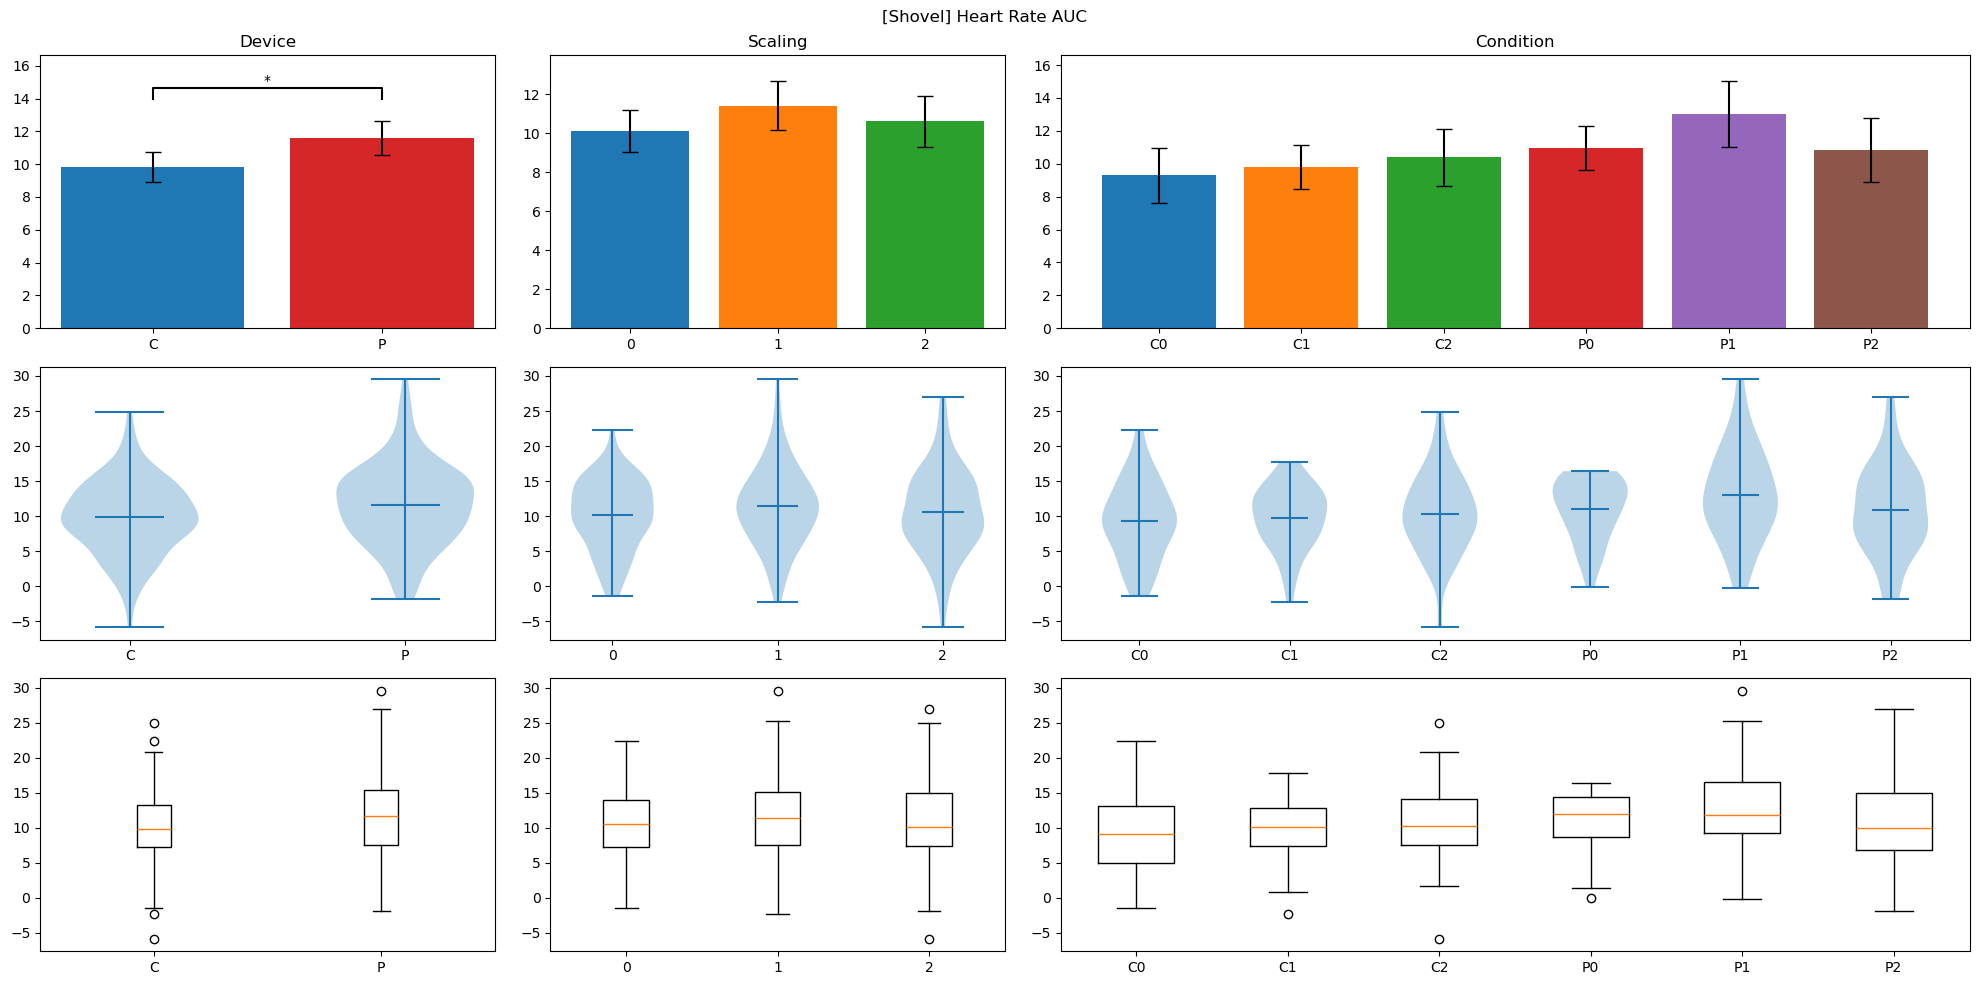

In [104]:
def hr_auc(p):
    return normalized_auc(p, hr_key)

title = 'Heart Rate AUC'
ylabel = ''
report_exeriment(data, hr_auc, cube, title, ylabel)
report_exeriment(data, hr_auc, shovel, title, ylabel)

[Cube] C0 subject 11_SePe is outlier
[Cube] C1 subject 11_SePe is outlier
[Cube] C2 subject 11_SePe is outlier
[Cube] P0 subject 5_MaGo is outlier
[Cube] P1 subject 11_SePe is outlier
[Cube] P2 subject 3_JuRo is outlier
[Cube] dropping subject 5_MaGo
[Cube] dropping subject 3_JuRo
[Cube] dropping subject 11_SePe
------ [Cube] Skin Conductance Delta: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.877959,1,38,2.877959,5.450059,0.024953,0.024953,0.021531,1.000000,✅
1,Scaling,0.047618,2,76,0.023809,0.150091,0.860885,0.839223,0.000364,0.899283,❌
2,Device * Scaling,0.709172,2,76,0.354586,1.709355,0.187866,0.194018,0.005393,0.812606,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.334536,38.0,two-sided,0.024953,NaN,NaN,1.905,-0.326786,✅


------ [Cube] Skin Conductance Delta: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,3.634749,5,0.72695,2.884263,0.015553,0.033352,0.02704,0.665634,False,0.303329,0.000086,✅
1,Error,47.887609,190,0.25204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.282621,38.0,two-sided,0.207394,1.000000,holm,0.368,-0.188354,❌
1,Condition,C0,C2,True,True,-1.803025,38.0,two-sided,0.079319,0.793187,holm,0.75,-0.261625,❌
2,Condition,C0,P0,True,True,-3.009443,38.0,two-sided,0.004629,0.069437,holm,7.988,-0.531547,🟨
3,Condition,C0,P1,True,True,-2.644759,38.0,two-sided,0.011820,0.165474,holm,3.568,-0.418212,❌
4,Condition,C0,P2,True,True,-2.316035,38.0,two-sided,0.026048,0.338628,holm,1.839,-0.397369,❌
5,Condition,C1,C2,True,True,-0.212846,38.0,two-sided,0.832585,1.000000,holm,0.176,-0.027185,❌
6,Condition,C1,P0,True,True,-2.046432,38.0,two-sided,0.047678,0.524454,holm,1.122,-0.288102,❌
7,Condition,C1,P1,True,True,-1.270393,38.0,two-sided,0.211668,1.000000,holm,0.363,-0.204904,❌
8,Condition,C1,P2,True,True,-0.878724,38.0,two-sided,0.385074,1.000000,holm,0.247,-0.165393,❌
9,Condition,C2,P0,True,True,-2.120480,38.0,two-sided,0.040551,0.486615,holm,1.279,-0.298499,❌


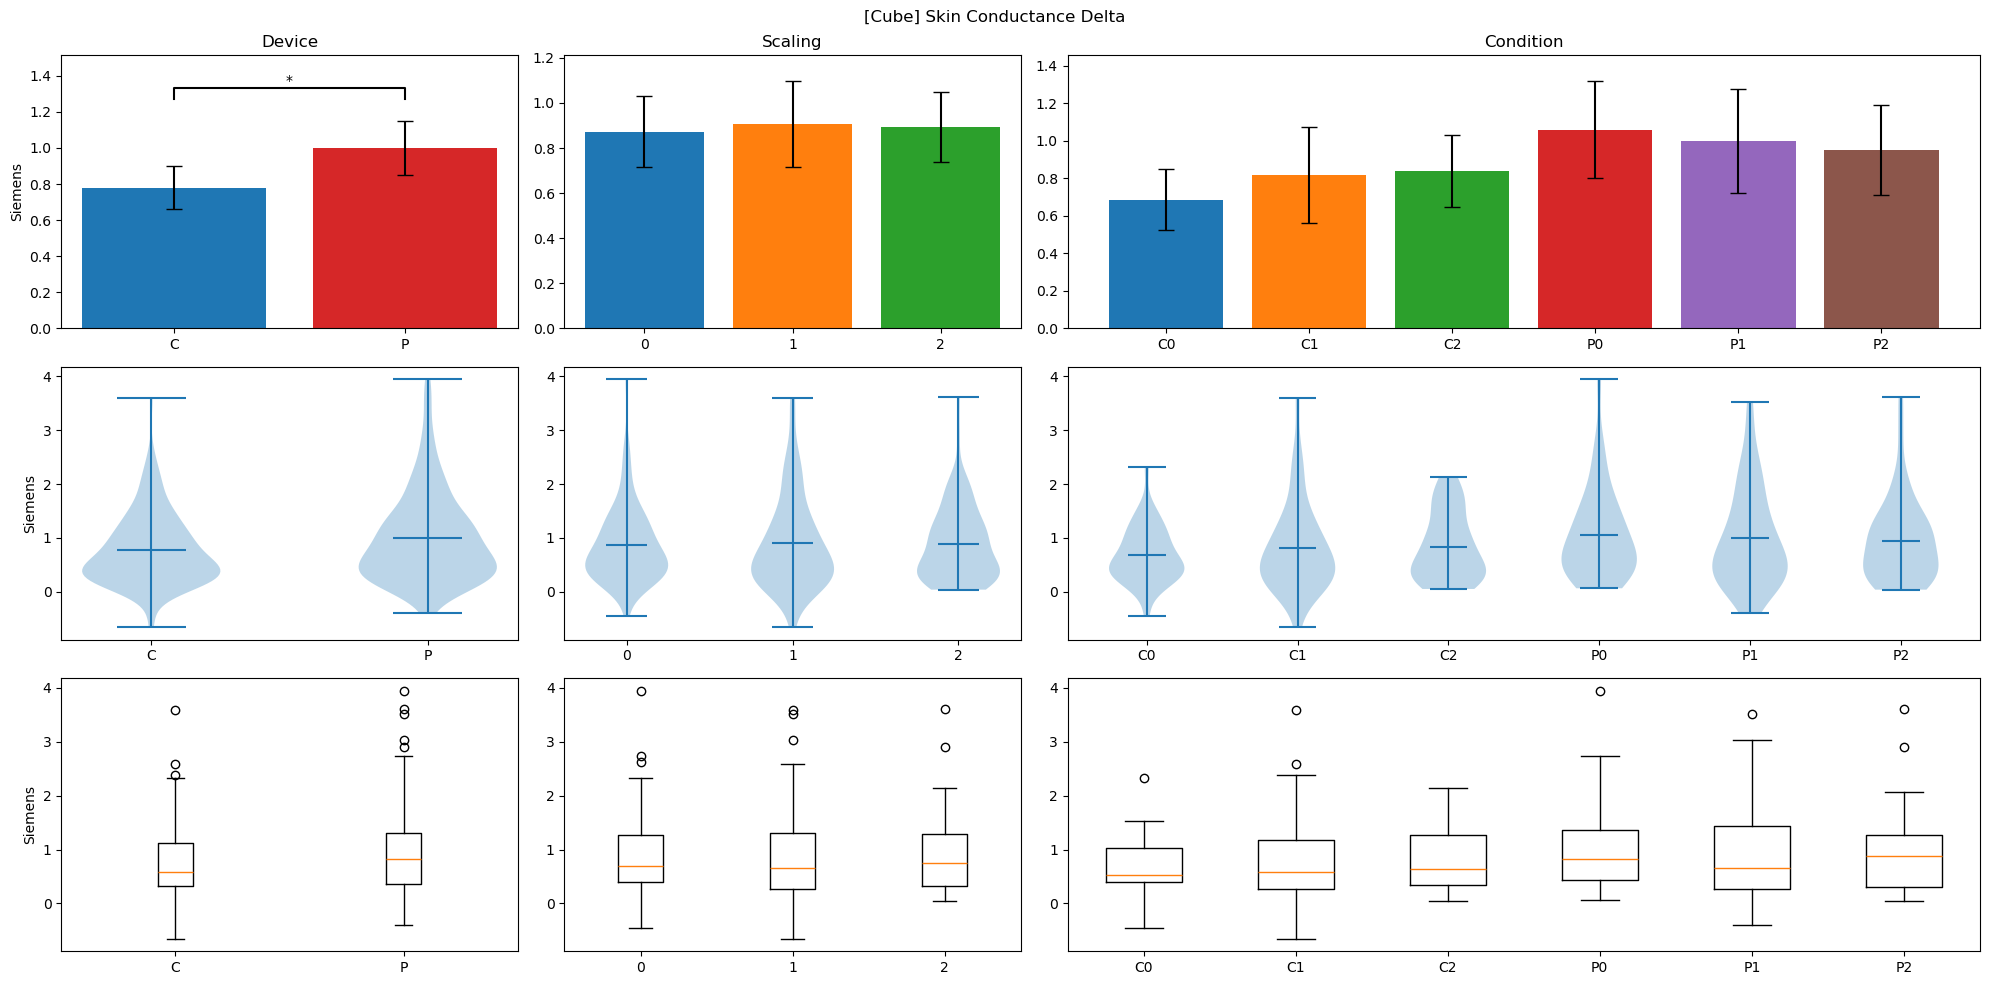

[Shovel] C0 subject 11_SePe is outlier
[Shovel] C1 subject 40_HeSe is outlier
[Shovel] C2 subject 11_SePe is outlier
[Shovel] P1 subject 40_HeSe is outlier
[Shovel] P2 subject 35_FlRu is outlier
[Shovel] dropping subject 35_FlRu
[Shovel] dropping subject 40_HeSe
[Shovel] dropping subject 11_SePe
------ [Shovel] Skin Conductance Delta: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,18.579965,1,38,18.579965,24.281274,0.000017,0.000017,0.086678,1.000000,✅
1,Scaling,0.225752,2,76,0.112876,0.516202,0.598860,0.592214,0.001152,0.963562,❌
2,Device * Scaling,0.726545,2,76,0.363272,0.904928,0.408885,0.378400,0.003697,0.700655,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.927603,38.0,two-sided,0.000017,NaN,NaN,1262.874,-0.691052,✅


------ [Shovel] Skin Conductance Delta: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,19.532261,5,3.906452,9.73981,2.678762e-08,0.000006,0.090718,0.62407,False,0.243709,0.000004,✅
1,Error,76.205380,190,0.401081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.409978,38.0,two-sided,0.684125,1.000000,holm,0.187,0.055350,❌
1,Condition,C0,C2,True,True,-0.398003,38.0,two-sided,0.692855,1.000000,holm,0.186,-0.041822,❌
2,Condition,C0,P0,True,True,-4.678124,38.0,two-sided,0.000036,0.000469,holm,620.356,-0.679776,✅
3,Condition,C0,P1,True,True,-5.057874,38.0,two-sided,0.000011,0.000166,holm,1836.993,-0.681429,✅
4,Condition,C0,P2,True,True,-2.419640,38.0,two-sided,0.020429,0.163430,holm,2.25,-0.481570,❌
5,Condition,C1,C2,True,True,-0.575774,38.0,two-sided,0.568162,1.000000,holm,0.202,-0.093316,❌
6,Condition,C1,P0,True,True,-5.014110,38.0,two-sided,0.000013,0.000178,holm,1619.302,-0.703896,✅
7,Condition,C1,P1,True,True,-4.225139,38.0,two-sided,0.000144,0.001584,holm,175.699,-0.705258,✅
8,Condition,C1,P2,True,True,-3.103450,38.0,two-sided,0.003602,0.032417,holm,9.939,-0.513528,✅
9,Condition,C2,P0,True,True,-3.781148,38.0,two-sided,0.000537,0.005374,holm,53.565,-0.618740,✅


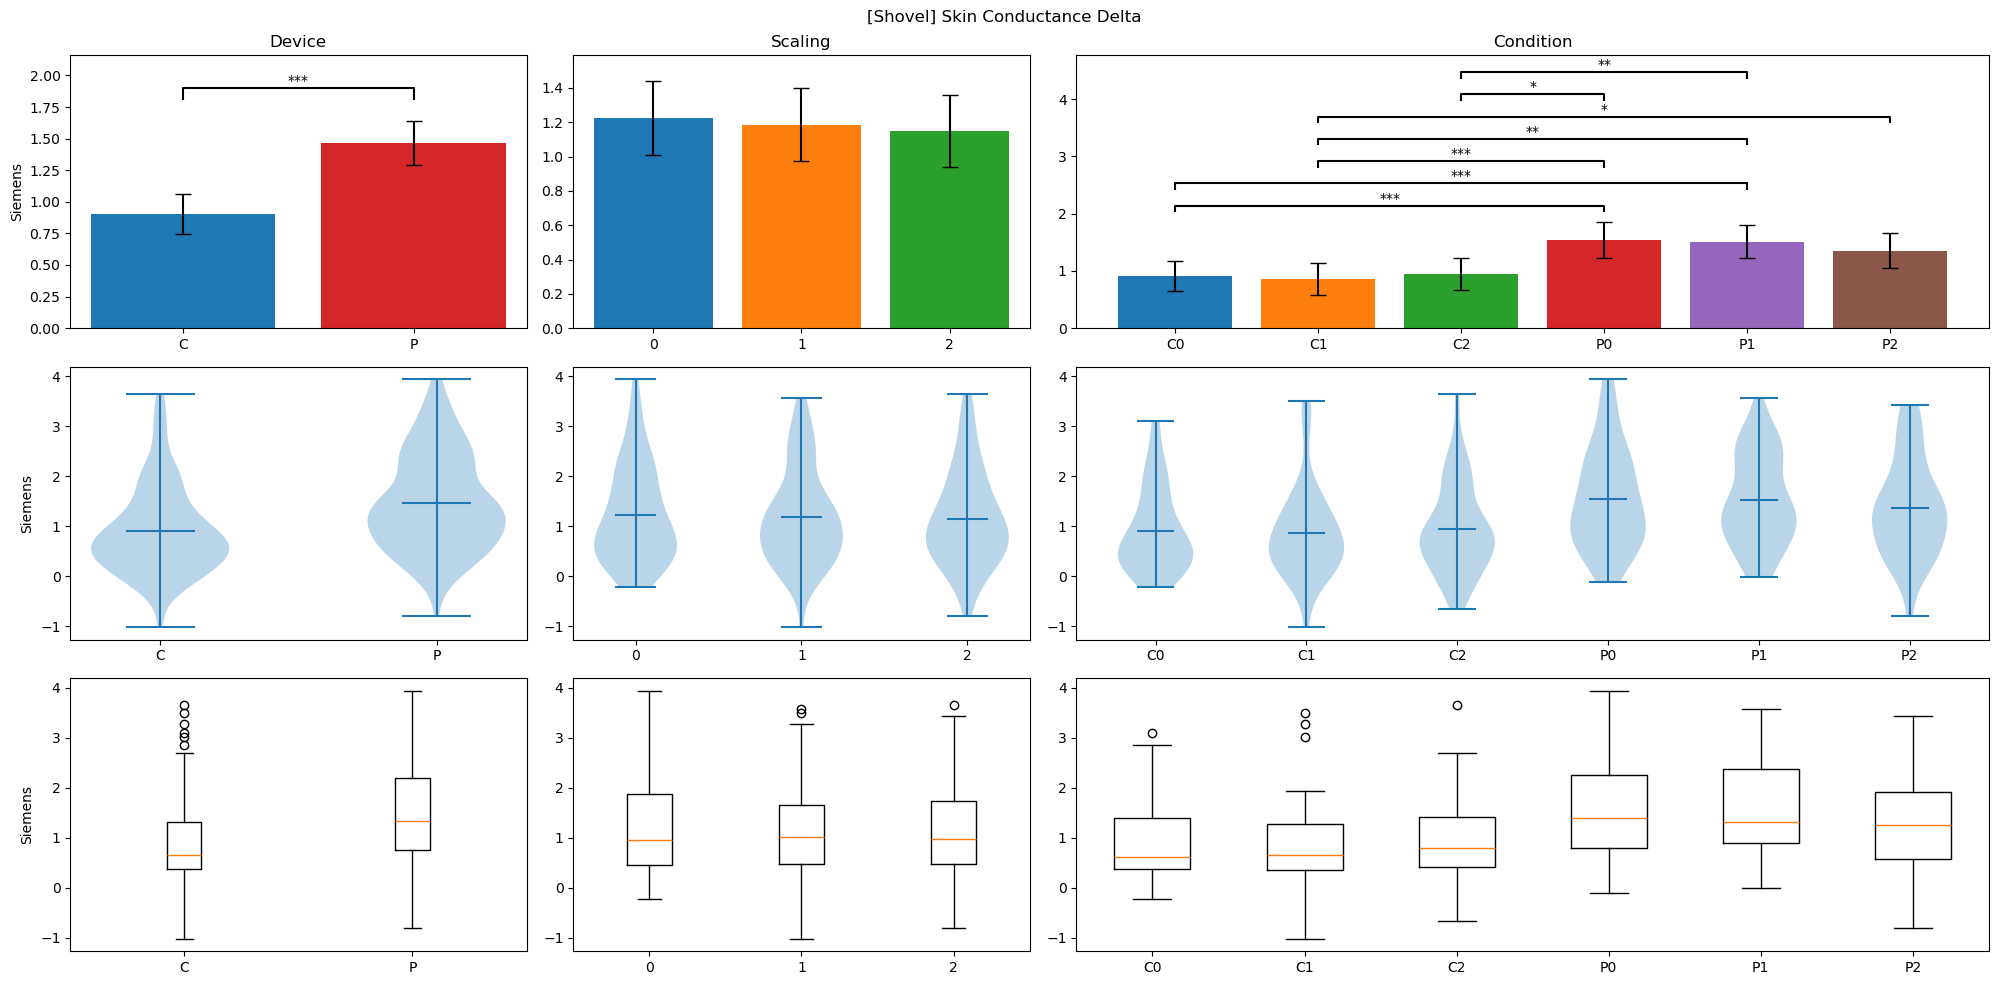

In [105]:
def gsr_con_delta(p):
    return pre_post_delta(p, gsr_con_key)

title = 'Skin Conductance Delta'
ylabel = 'Siemens'
report_exeriment(data, gsr_con_delta, cube, title, ylabel)
report_exeriment(data, gsr_con_delta, shovel, title, ylabel)

[Cube] C0 subject 23_DaMe is outlier
[Cube] C1 subject 3_JuRo is outlier
[Cube] C2 subject 3_JuRo is outlier
[Cube] C2 subject 11_SePe is outlier
[Cube] P1 subject 11_SePe is outlier
[Cube] P2 subject 3_JuRo is outlier
[Cube] dropping subject 3_JuRo
[Cube] dropping subject 23_DaMe
[Cube] dropping subject 11_SePe
------ [Cube] Skin Conductance AUC: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.414381,1,38,2.414381,4.584590,0.038736,0.038736,0.018950,1.000000,✅
1,Scaling,0.116731,2,76,0.058366,0.401698,0.670595,0.632754,0.000933,0.830616,❌
2,Device * Scaling,0.507280,2,76,0.253640,1.305819,0.276960,0.276016,0.004042,0.910106,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.141166,38.0,two-sided,0.038736,NaN,NaN,1.328,-0.304961,✅


------ [Cube] Skin Conductance AUC: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,3.038392,5,0.607678,2.520021,0.030957,0.055085,0.023732,0.663277,False,0.271166,0.000019,🟨
1,Error,45.816649,190,0.241140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


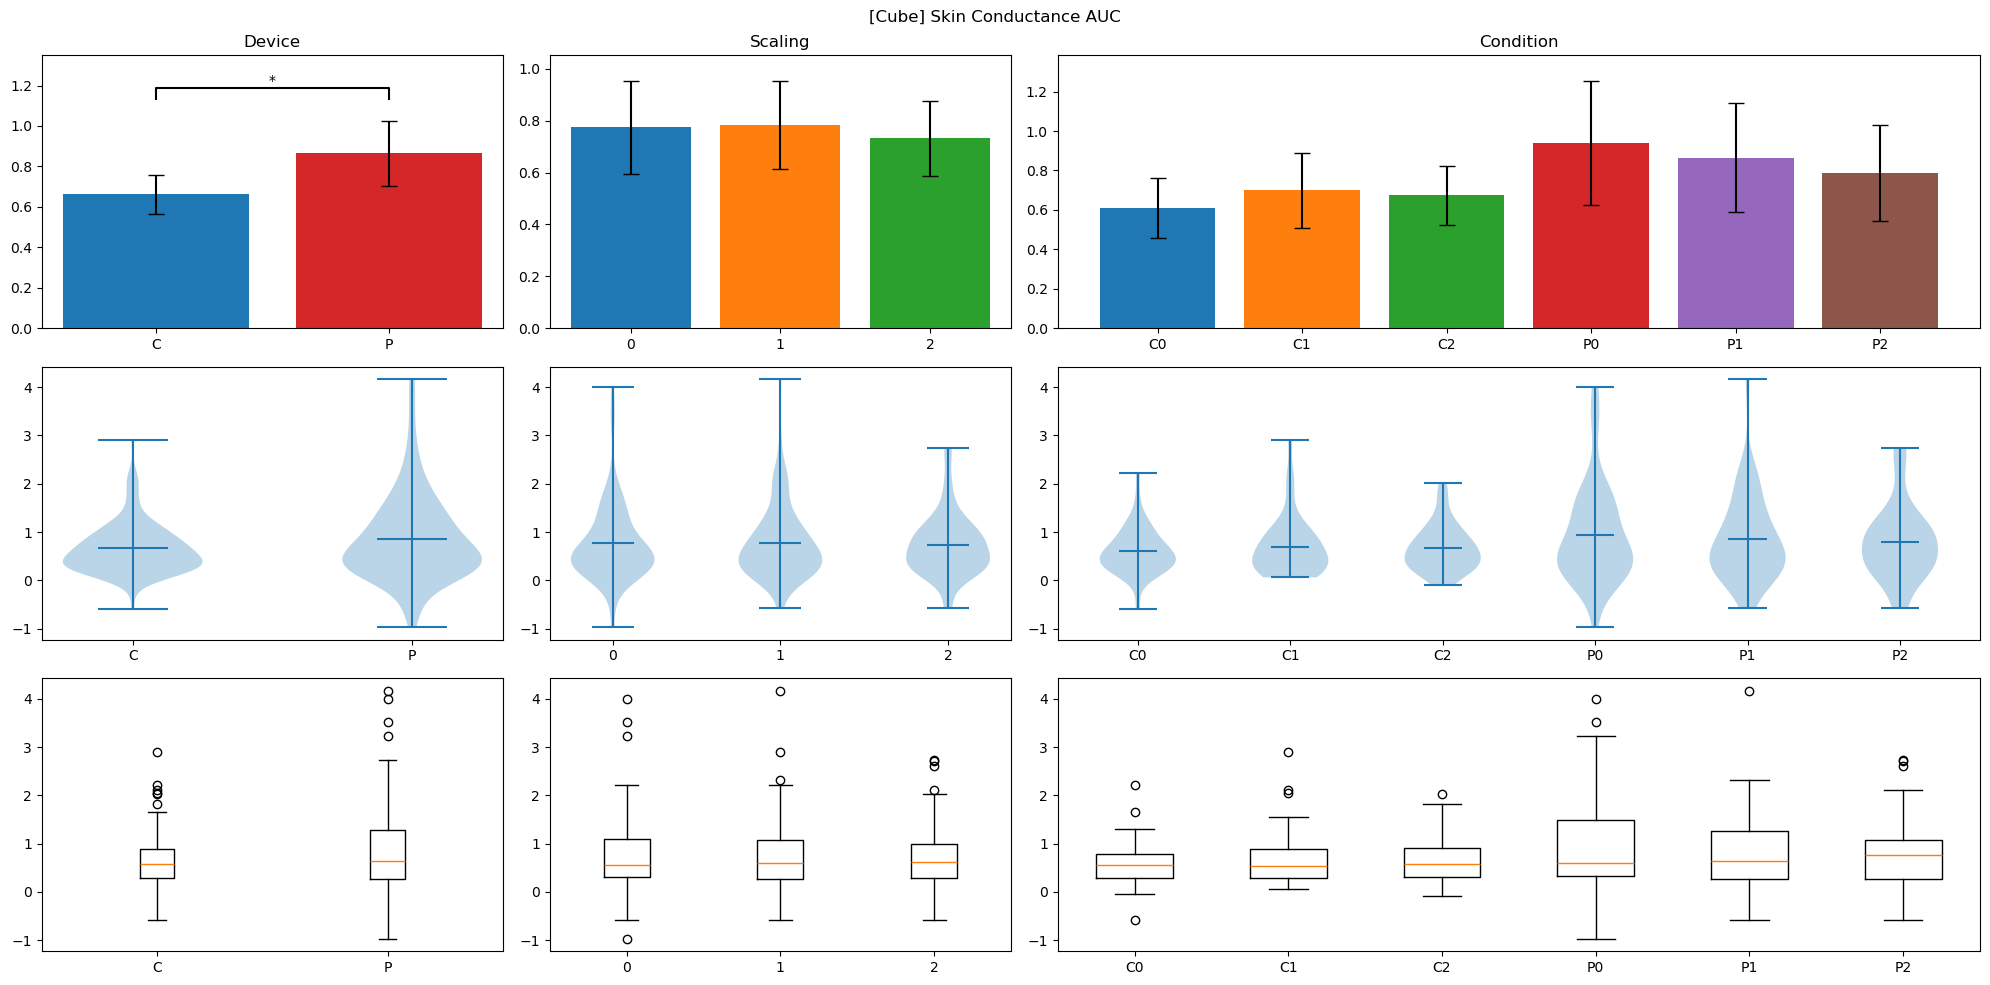

[Shovel] C0 subject 11_SePe is outlier
[Shovel] C1 subject 40_HeSe is outlier
[Shovel] C2 subject 11_SePe is outlier
[Shovel] P2 subject 11_SePe is outlier
[Shovel] dropping subject 40_HeSe
[Shovel] dropping subject 11_SePe
------ [Shovel] Skin Conductance AUC: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,54.980905,1,39,54.980905,49.393095,1.961506e-08,1.961506e-08,0.217146,1.000000,✅
1,Scaling,0.163232,2,78,0.081616,0.342470,7.110764e-01,6.956090e-01,0.000823,0.930038,❌
2,Device * Scaling,0.491819,2,78,0.245909,0.760277,4.709697e-01,4.568938e-01,0.002475,0.887299,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-7.028022,39.0,two-sided,1.961506e-08,NaN,NaN,6.805e+05,-1.167092,✅


------ [Shovel] Skin Conductance AUC: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,55.635956,5,11.127191,24.874634,2.362723e-19,5.871865e-12,0.219166,0.567135,False,0.128604,1.631329e-10,✅
1,Error,87.229517,195,0.447331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.263610,39.0,two-sided,7.934685e-01,1.000000e+00,holm,0.176,0.028311,❌
1,Condition,C0,C2,True,True,-0.370091,39.0,two-sided,7.133170e-01,1.000000e+00,holm,0.182,-0.053565,❌
2,Condition,C0,P0,True,True,-7.330834,39.0,two-sided,7.562531e-09,1.134380e-07,holm,1.674e+06,-1.111236,✅
3,Condition,C0,P1,True,True,-6.854464,39.0,two-sided,3.397041e-08,4.755857e-07,holm,4.055e+05,-1.053801,✅
4,Condition,C0,P2,True,True,-5.029729,39.0,two-sided,1.140216e-05,1.026194e-04,holm,1780.005,-0.882943,✅
5,Condition,C1,C2,True,True,-0.540648,39.0,two-sided,5.918246e-01,1.000000e+00,holm,0.196,-0.089866,❌
6,Condition,C1,P0,True,True,-6.673498,39.0,two-sided,6.034281e-08,7.844565e-07,holm,2.361e+05,-1.184598,✅
7,Condition,C1,P1,True,True,-6.137199,39.0,two-sided,3.339393e-07,4.007272e-06,holm,4.742e+04,-1.118796,✅
8,Condition,C1,P2,True,True,-4.794718,39.0,two-sided,2.388507e-05,1.910806e-04,holm,901.029,-0.938276,✅
9,Condition,C2,P0,True,True,-6.116478,39.0,two-sided,3.568152e-07,4.007272e-06,holm,4.457e+04,-1.102317,✅


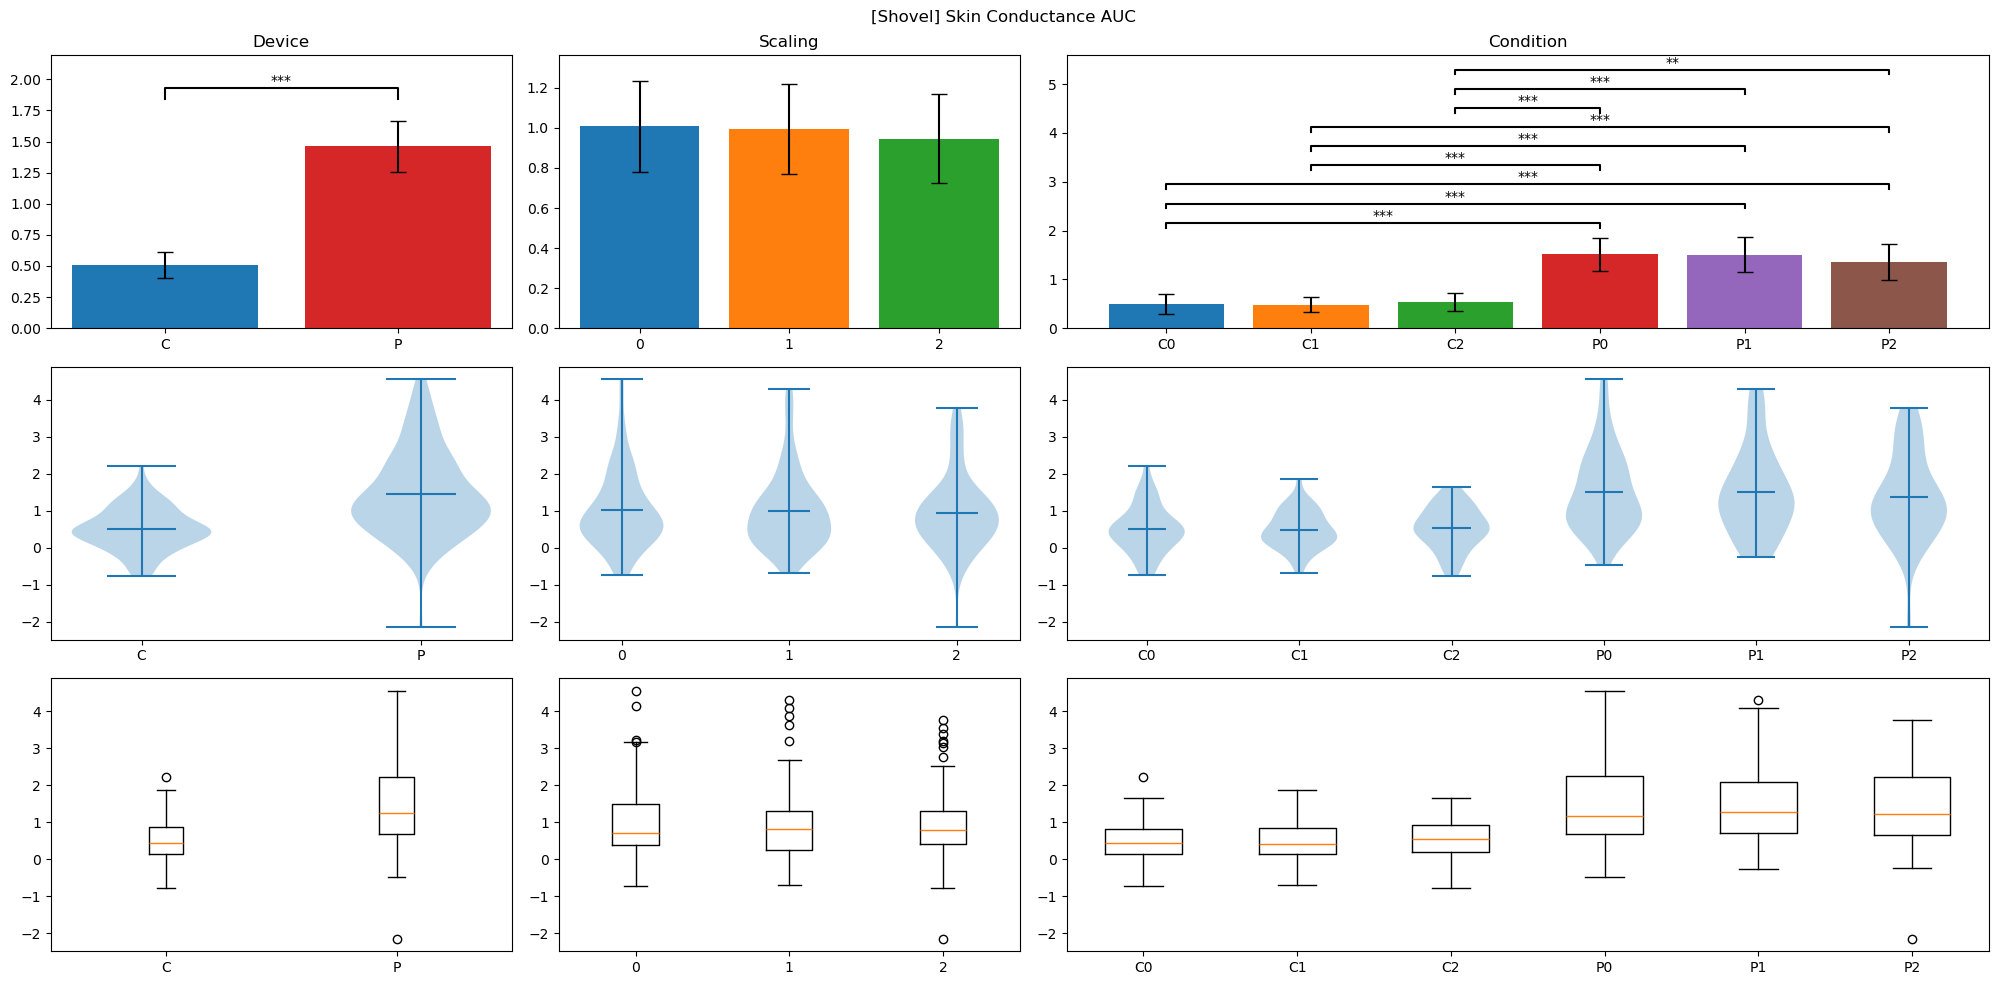

In [106]:
def gsr_con_auc(p):
    return normalized_auc(p, gsr_con_key)

title = 'Skin Conductance AUC'
ylabel = ''
report_exeriment(data, gsr_con_auc, cube, title, ylabel)
report_exeriment(data, gsr_con_auc, shovel, title, ylabel)

[Cube] C0 subject 1_AlDe is outlier
[Cube] C1 subject 26_BaBa is outlier
[Cube] dropping subject 1_AlDe
[Cube] dropping subject 26_BaBa
------ [Cube] Task Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,325.904112,1,39,325.904112,6.293008,0.016389,0.016389,0.019905,1.000000,✅
1,Scaling,449.749562,2,78,224.874781,4.622485,0.012671,0.022285,0.027263,0.742026,✅
2,Device * Scaling,34.950647,2,78,17.475324,0.426314,0.654423,0.602503,0.002173,0.770264,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.508587,39.0,two-sided,0.016389,NaN,NaN,2.681,-0.371038,✅
1,Scaling,-,0,1,True,True,0.210950,39.0,two-sided,0.834024,0.834024,holm,0.174,0.031763,❌
2,Scaling,-,0,2,True,True,-2.014686,39.0,two-sided,0.050870,0.101739,holm,1.055,-0.365620,❌
3,Scaling,-,1,2,True,True,-3.236727,39.0,two-sided,0.002469,0.007406,holm,13.723,-0.446663,✅


------ [Cube] Task Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,810.604322,5,162.120864,3.508083,0.004647,0.011628,0.048085,0.722765,False,0.356086,0.000477,✅
1,Error,9011.636683,195,46.213521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.708044,39.0,two-sided,0.483128,1.000000,holm,0.216,0.110875,❌
1,Condition,C0,C2,True,True,-1.120123,39.0,two-sided,0.269512,1.000000,holm,0.305,-0.209826,❌
2,Condition,C0,P0,True,True,-0.935234,39.0,two-sided,0.355423,1.000000,holm,0.256,-0.152519,❌
3,Condition,C0,P1,True,True,-1.116347,39.0,two-sided,0.271105,1.000000,holm,0.304,-0.230865,❌
4,Condition,C0,P2,True,True,-2.369453,39.0,two-sided,0.022859,0.320030,holm,2.029,-0.505122,❌
5,Condition,C1,C2,True,True,-1.919930,39.0,two-sided,0.062203,0.622025,holm,0.899,-0.347478,❌
6,Condition,C1,P0,True,True,-1.670320,39.0,two-sided,0.102864,0.880084,holm,0.608,-0.298137,❌
7,Condition,C1,P1,True,True,-2.137503,39.0,two-sided,0.038883,0.505473,holm,1.311,-0.418064,❌
8,Condition,C1,P2,True,True,-3.828284,39.0,two-sided,0.000456,0.006839,holm,61.641,-0.659739,✅
9,Condition,C2,P0,True,True,0.413318,39.0,two-sided,0.681638,1.000000,holm,0.185,0.072727,❌


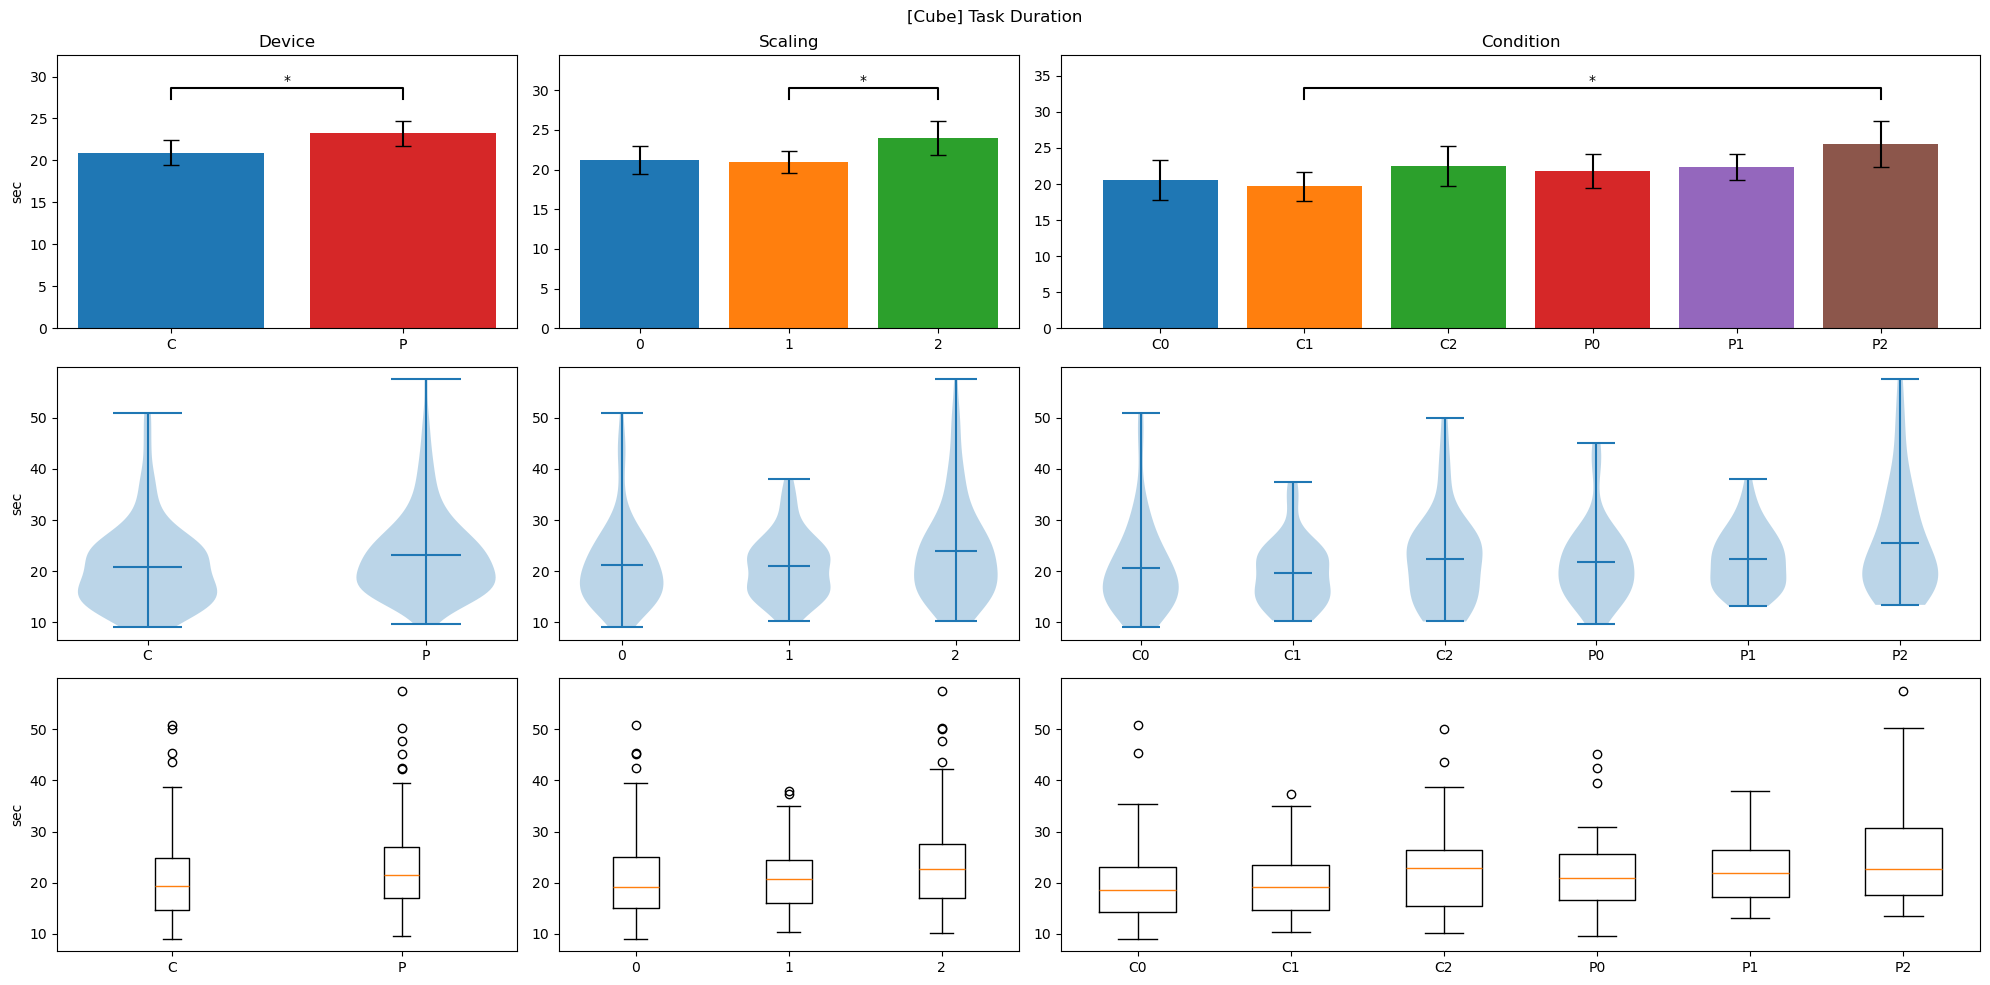

[Shovel] C1 subject 2_ReDo is outlier
[Shovel] C2 subject 22_ClSt is outlier
[Shovel] dropping subject 22_ClSt
[Shovel] dropping subject 2_ReDo
------ [Shovel] Task Duration: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,19.036724,1,39,19.036724,0.128765,7.216509e-01,7.216509e-01,0.000300,1.000000,❌
1,Scaling,6468.766763,2,78,3234.383381,23.845035,8.297583e-09,7.694285e-07,0.092465,0.704556,✅
2,Device * Scaling,92.095102,2,78,46.047551,0.448213,6.404033e-01,6.027746e-01,0.001448,0.823930,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.794107,39.0,two-sided,0.008028,0.008028,holm,4.921,-0.260100,✅
2,Scaling,-,0,2,True,True,-5.287703,39.0,two-sided,0.000005,0.000015,holm,3790.168,-0.817877,✅
3,Scaling,-,1,2,True,True,-5.101965,39.0,two-sided,0.000009,0.000018,holm,2197.776,-0.593885,✅


------ [Shovel] Task Duration: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,6579.898588,5,1315.979718,10.534655,5.742923e-09,5.892515e-07,0.093904,0.710229,False,0.297655,0.000043,✅
1,Error,24359.227084,195,124.919113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.456932,39.0,two-sided,0.153140,0.765700,holm,0.452,-0.189302,❌
1,Condition,C0,C2,True,True,-4.255644,39.0,two-sided,0.000127,0.001645,holm,196.26,-0.790754,✅
2,Condition,C0,P0,True,True,-0.263277,39.0,two-sided,0.793723,1.000000,holm,0.176,-0.032894,❌
3,Condition,C0,P1,True,True,-1.825202,39.0,two-sided,0.075636,0.453818,holm,0.771,-0.304900,❌
4,Condition,C0,P2,True,True,-3.777500,39.0,two-sided,0.000529,0.005822,holm,53.912,-0.725929,✅
5,Condition,C1,C2,True,True,-3.808937,39.0,two-sided,0.000483,0.005792,holm,58.568,-0.626862,✅
6,Condition,C1,P0,True,True,1.186223,39.0,two-sided,0.242711,0.970843,holm,0.327,0.152389,❌
7,Condition,C1,P1,True,True,-0.783028,39.0,two-sided,0.438340,1.000000,holm,0.227,-0.129038,❌
8,Condition,C1,P2,True,True,-3.531402,39.0,two-sided,0.001079,0.010795,holm,28.524,-0.562163,✅
9,Condition,C2,P0,True,True,5.220707,39.0,two-sided,0.000006,0.000093,holm,3112.406,0.746885,✅


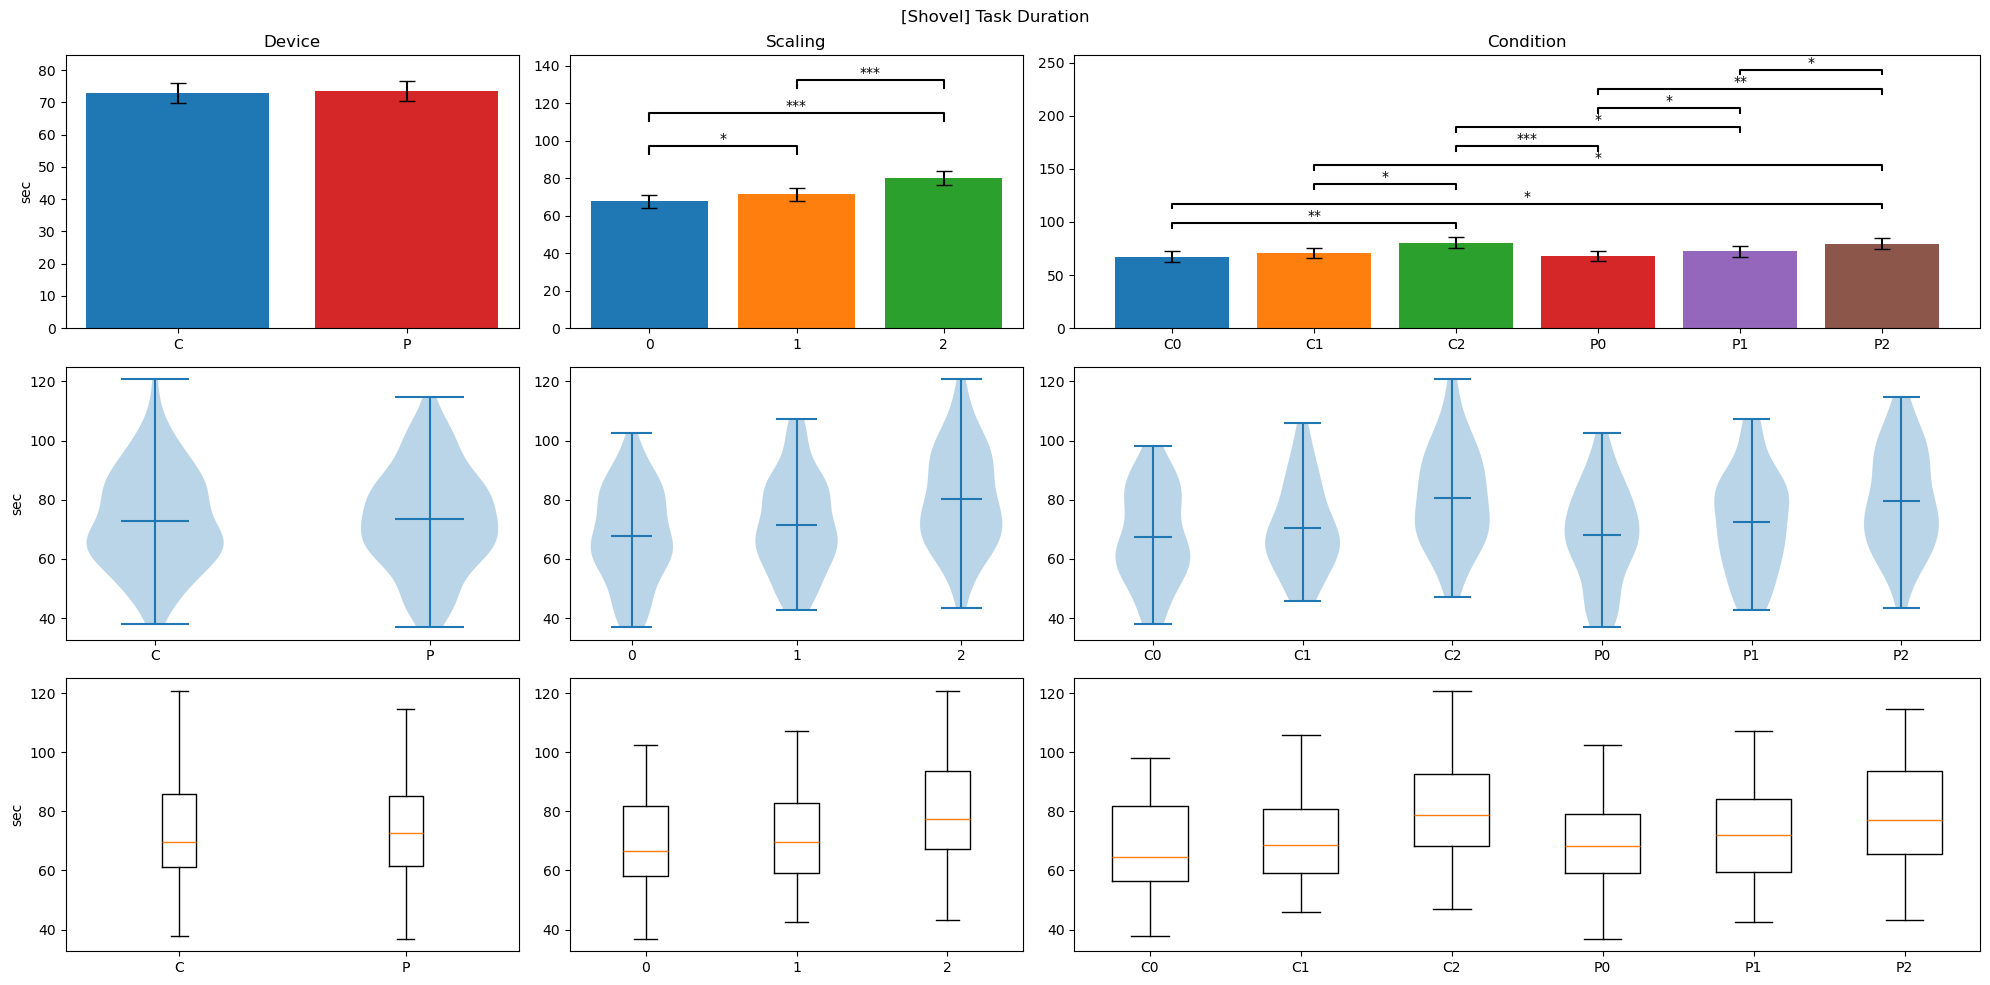

In [107]:
def task_duration(p):
    return (p[end_ts] - p[start_ts]) / 1_000

title = 'Task Duration'
ylabel = 'sec'
report_exeriment(data, task_duration, cube, title, ylabel)
report_exeriment(data, task_duration, shovel, title, ylabel)

[Cube] C0 subject 25_LeSc is outlier
[Cube] C1 subject 13_FaPu is outlier
[Cube] C2 subject 13_FaPu is outlier
[Cube] P2 subject 32_AnRa is outlier
[Cube] dropping subject 25_LeSc
[Cube] dropping subject 13_FaPu
[Cube] dropping subject 32_AnRa
------ [Cube] Head Travel Path Distance: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,44.777252,1,38,44.777252,6.667318,0.013799,0.013799,0.024454,1.000000,✅
1,Scaling,74.670617,2,76,37.335309,5.085650,0.008455,0.019704,0.040125,0.665643,✅
2,Device * Scaling,0.759207,2,76,0.379603,0.089306,0.914662,0.894287,0.000425,0.888098,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.582115,38.0,two-sided,0.013799,NaN,NaN,3.129,-0.434712,✅
1,Scaling,-,0,1,True,True,-0.688732,38.0,two-sided,0.495176,0.495176,holm,0.215,-0.093383,❌
2,Scaling,-,0,2,True,True,-2.315241,38.0,two-sided,0.026096,0.052193,holm,1.836,-0.501991,🟨
3,Scaling,-,1,2,True,True,-2.556148,38.0,two-sided,0.014705,0.044115,holm,2.966,-0.462337,✅


------ [Cube] Head Travel Path Distance: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,120.207076,5,24.041415,4.020338,0.001721,0.006177,0.063052,0.694847,False,0.30684,0.0001,✅
1,Error,1136.190252,190,5.979949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.817456,38.0,two-sided,0.418764,1.000000,holm,0.236,-0.126758,❌
1,Condition,C0,C2,True,True,-2.224912,38.0,two-sided,0.032100,0.353104,holm,1.548,-0.473088,❌
2,Condition,C0,P0,True,True,-2.397193,38.0,two-sided,0.021544,0.258522,holm,2.153,-0.393814,❌
3,Condition,C0,P1,True,True,-2.668334,38.0,two-sided,0.011145,0.144886,holm,3.751,-0.479898,❌
4,Condition,C0,P2,True,True,-3.131571,38.0,two-sided,0.003339,0.050087,holm,10.618,-0.725582,🟨
5,Condition,C1,C2,True,True,-1.823378,38.0,two-sided,0.076120,0.685078,holm,0.775,-0.362401,❌
6,Condition,C1,P0,True,True,-1.450104,38.0,two-sided,0.155234,0.931403,holm,0.452,-0.270278,❌
7,Condition,C1,P1,True,True,-1.667537,38.0,two-sided,0.103630,0.750592,holm,0.611,-0.336472,❌
8,Condition,C1,P2,True,True,-2.935868,38.0,two-sided,0.005619,0.078670,holm,6.752,-0.616711,🟨
9,Condition,C2,P0,True,True,0.541567,38.0,two-sided,0.591279,1.000000,holm,0.198,0.116786,❌


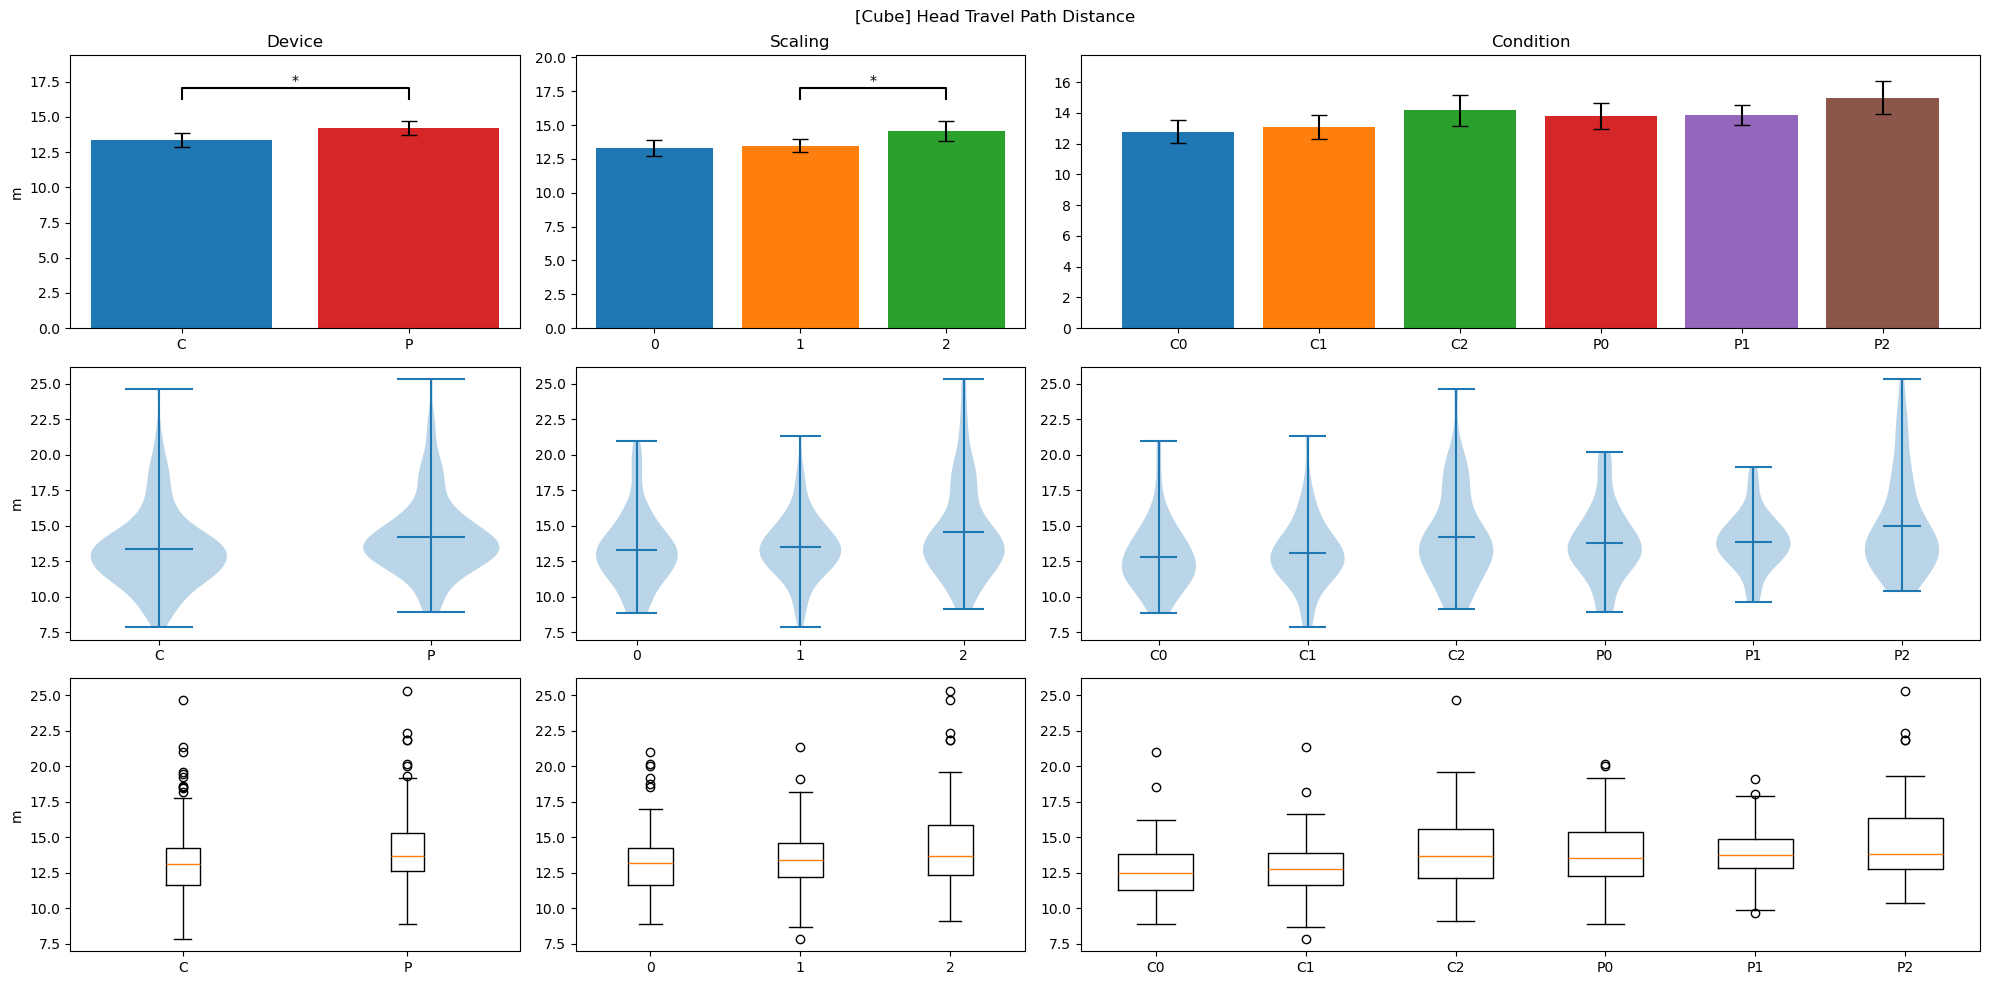

[Shovel] P1 subject 7_KlMe is outlier
[Shovel] P2 subject 7_KlMe is outlier
[Shovel] dropping subject 7_KlMe
------ [Shovel] Head Travel Path Distance: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,144.784930,1,40,144.784930,4.657603,0.036974,0.036974,0.006481,1.000000,✅
1,Scaling,915.834554,2,80,457.917277,12.386346,0.000021,0.000091,0.039629,0.812074,✅
2,Device * Scaling,74.277797,2,80,37.138899,1.251898,0.291502,0.286243,0.003335,0.782694,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.158148,40.0,two-sided,0.036974,NaN,NaN,1.352,-0.181321,✅
1,Scaling,-,0,1,True,True,-2.580661,40.0,two-sided,0.013636,0.013636,holm,3.104,-0.243385,✅
2,Scaling,-,0,2,True,True,-4.086445,40.0,two-sided,0.000205,0.000614,holm,126.043,-0.522822,✅
3,Scaling,-,1,2,True,True,-3.132311,40.0,two-sided,0.003239,0.006478,holm,10.726,-0.293360,✅


------ [Shovel] Head Travel Path Distance: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,1134.897282,5,226.979456,6.905079,0.000006,0.000047,0.048646,0.77593,False,0.416241,0.002569,✅
1,Error,6574.275560,200,32.871378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.763843,40.0,two-sided,0.085395,0.512372,holm,0.694,-0.217610,❌
1,Condition,C0,C2,True,True,-4.104569,40.0,two-sided,0.000194,0.002907,holm,132.483,-0.578359,✅
2,Condition,C0,P0,True,True,-2.205662,40.0,two-sided,0.033216,0.232511,holm,1.476,-0.237608,❌
3,Condition,C0,P1,True,True,-3.368189,40.0,two-sided,0.001684,0.021889,holm,19.081,-0.457561,✅
4,Condition,C0,P2,True,True,-3.810407,40.0,two-sided,0.000468,0.006559,holm,59.734,-0.606094,✅
5,Condition,C1,C2,True,True,-2.747769,40.0,two-sided,0.008956,0.089558,holm,4.442,-0.368439,🟨
6,Condition,C1,P0,True,True,-0.107950,40.0,two-sided,0.914575,1.000000,holm,0.17,-0.014605,❌
7,Condition,C1,P1,True,True,-1.685146,40.0,two-sided,0.099748,0.512372,holm,0.616,-0.236863,❌
8,Condition,C1,P2,True,True,-3.050948,40.0,two-sided,0.004039,0.048463,holm,8.846,-0.385995,✅
9,Condition,C2,P0,True,True,2.831519,40.0,two-sided,0.007217,0.079391,holm,5.347,0.363649,🟨


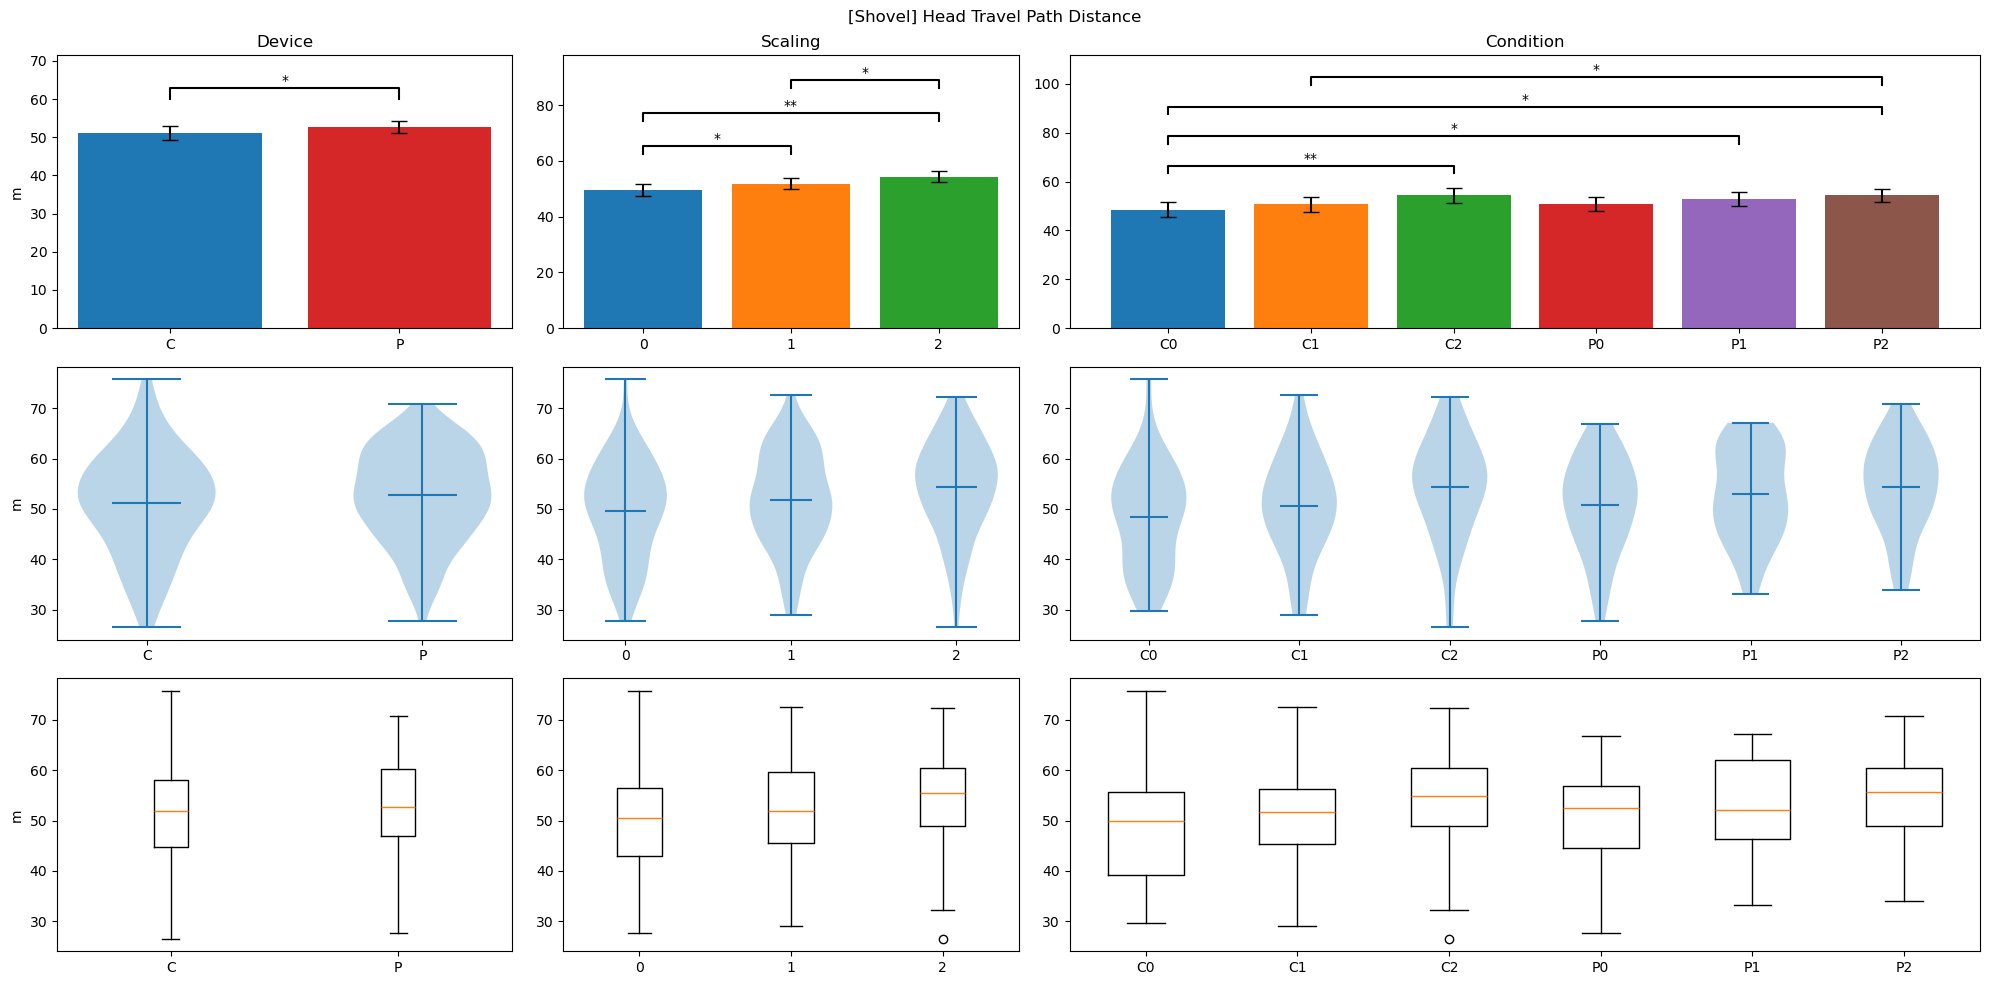

In [108]:
hmd = "hmd"

def single_pos_path_len(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    df[pt + "_x_delta"] = df[pt + "_x"].diff()
    df[pt + "_y_delta"] = df[pt + "_y"].diff()
    df[pt + "_z_delta"] = df[pt + "_z"].diff()

    df = df.dropna(subset = [pt + "_x_delta", pt + "_y_delta", pt + "_z_delta"])

    df["delta_dist"] = df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)

    return df["delta_dist"].sum()

def hmd_path_len_m(p):
    return single_pos_path_len(p, hmd)

title = 'Head Travel Path Distance'
ylabel = 'm'
report_exeriment(data, hmd_path_len_m, cube, title, ylabel)
report_exeriment(data, hmd_path_len_m, shovel, title, ylabel)

------ [Shovel] Average Hand Distance: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,144915.665754,1,41,144915.665754,21.445611,3.644724e-05,3.644724e-05,0.113962,1.000000,✅
1,Scaling,47863.699136,2,82,23931.849568,20.845784,4.790975e-08,2.046858e-07,0.040750,0.893294,✅
2,Device * Scaling,6456.889418,2,82,3228.444709,2.979550,5.634508e-02,6.436914e-02,0.005698,0.867399,🟨


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.630941,41.0,two-sided,0.000036,NaN,NaN,604.595,-0.767242,✅
1,Scaling,-,0,1,True,True,-4.349342,41.0,two-sided,0.000088,0.000177,holm,269.134,-0.382576,✅
2,Scaling,-,0,2,True,True,-5.505388,41.0,two-sided,0.000002,0.000007,holm,8170.08,-0.595064,✅
3,Scaling,-,1,2,True,True,-2.550874,41.0,two-sided,0.014575,0.014575,holm,2.908,-0.207796,✅


------ [Shovel] Average Hand Distance: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,199236.254308,5,39847.250862,17.756433,1.310410e-14,6.203668e-08,0.150261,0.463674,False,0.084573,2.427434e-14,✅
1,Error,460040.965215,205,2244.102269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-3.926408,41.0,two-sided,3.229205e-04,2.906285e-03,holm,82.948,-0.303145,✅
1,Condition,C0,C2,True,True,-4.656015,41.0,two-sided,3.366383e-05,4.039659e-04,holm,650.323,-0.573021,✅
2,Condition,C0,P0,True,True,-5.134399,41.0,two-sided,7.271615e-06,9.453100e-05,holm,2671.207,-0.860233,✅
3,Condition,C0,P1,True,True,-6.506717,41.0,two-sided,8.232030e-08,1.152484e-06,holm,1.754e+05,-1.150134,✅
4,Condition,C0,P2,True,True,-7.166474,41.0,two-sided,9.602954e-09,1.440443e-07,holm,1.33e+06,-1.196067,✅
5,Condition,C1,C2,True,True,-2.331042,41.0,two-sided,2.474789e-02,7.424368e-02,holm,1.865,-0.247085,🟨
6,Condition,C1,P0,True,True,-2.522520,41.0,two-sided,1.562749e-02,6.250998e-02,holm,2.741,-0.464511,🟨
7,Condition,C1,P1,True,True,-4.006618,41.0,two-sided,2.533611e-04,2.533611e-03,holm,103.274,-0.731580,✅
8,Condition,C1,P2,True,True,-4.423298,41.0,two-sided,7.007637e-05,7.708401e-04,holm,332.284,-0.773952,✅
9,Condition,C2,P0,True,True,-1.047163,41.0,two-sided,3.011589e-01,6.023177e-01,holm,0.278,-0.189571,❌


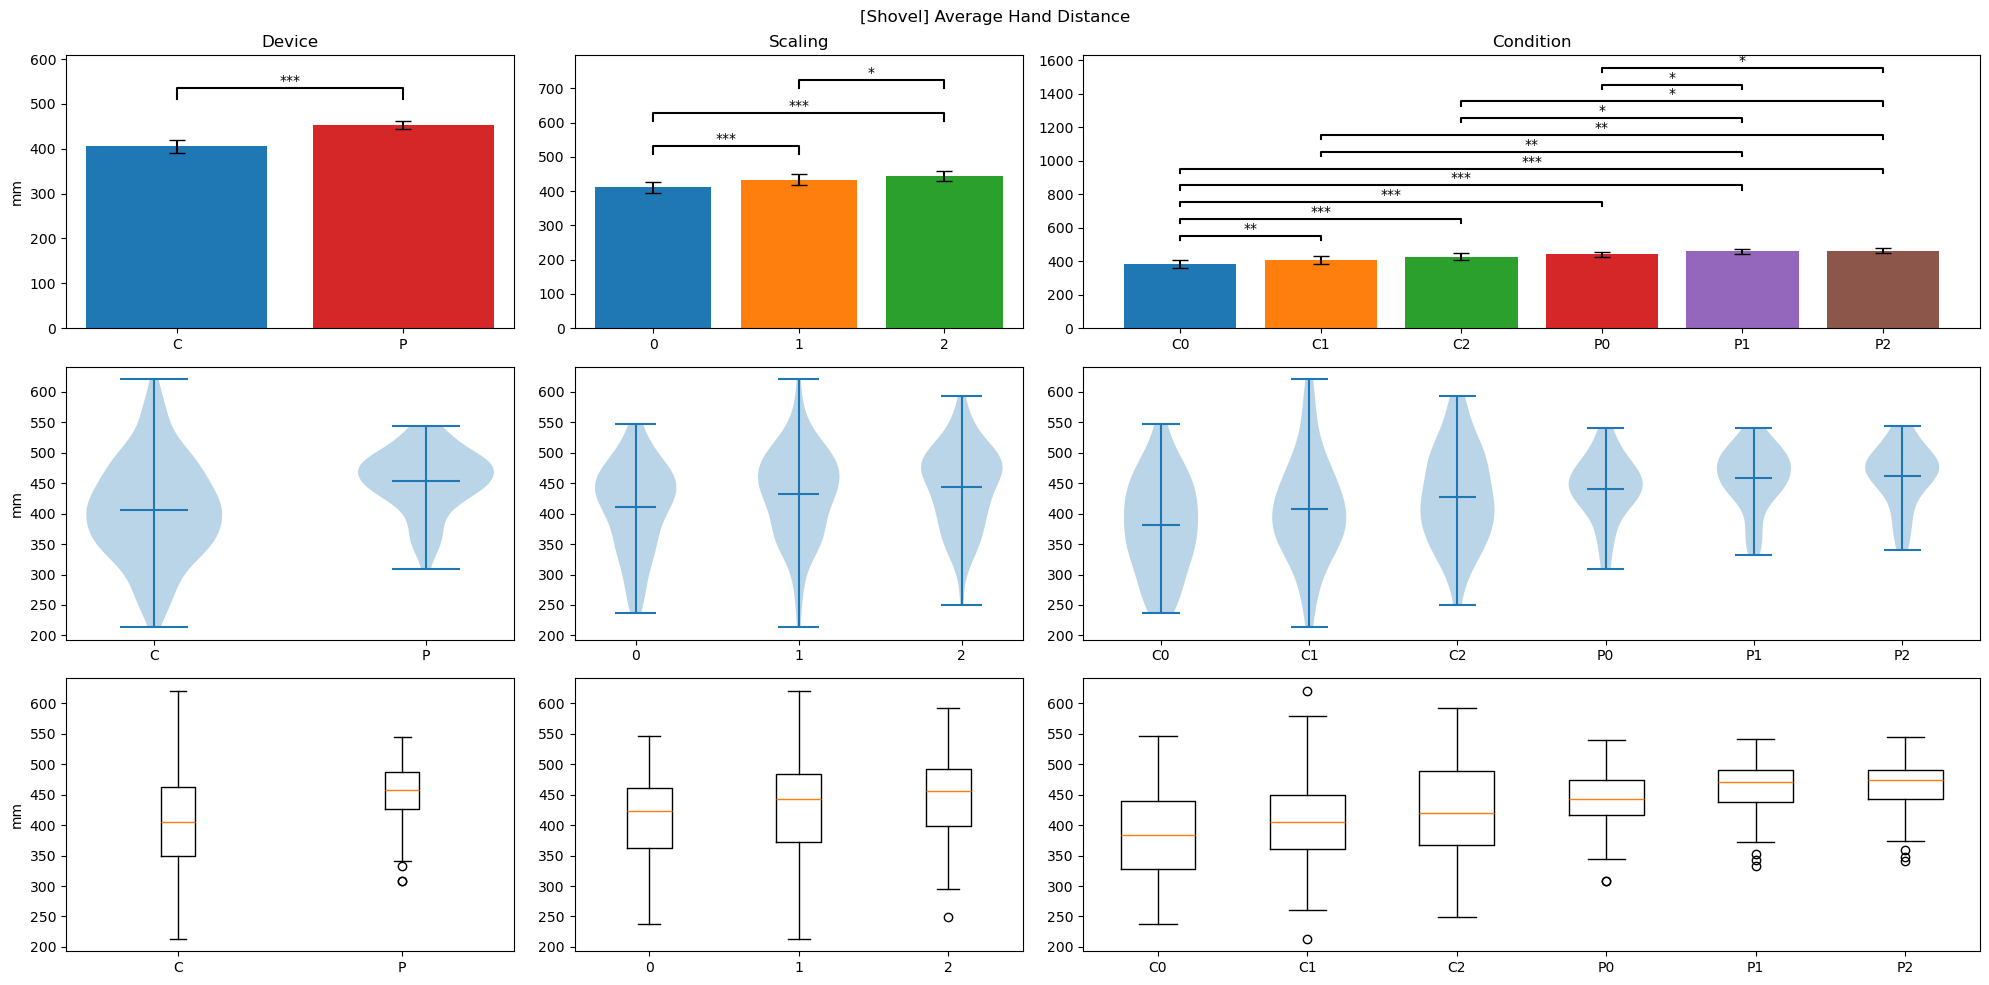

In [109]:
primary_tracked = "pt"
secondary_tracked = "st"
primary_visible = "pv"
secondary_visible = "sv"

def mean_pt_dist(p, pt_1, pt_2):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    df["dist"] = df.apply(lambda x: distance.euclidean((x[pt_1 + "_x"], x[pt_1 + "_y"], x[pt_1 + "_z"]), (x[pt_2 + "_x"], x[pt_2 + "_y"], x[pt_2 + "_z"])), axis = 1)
    return df["dist"].mean()

def tracked_hand_dist_mm(p):
    return mean_pt_dist(p, primary_tracked, secondary_tracked) * 1_000

title = "Average Hand Distance"
ylabel = "mm"
report_exeriment(data, tracked_hand_dist_mm, shovel, title, ylabel)

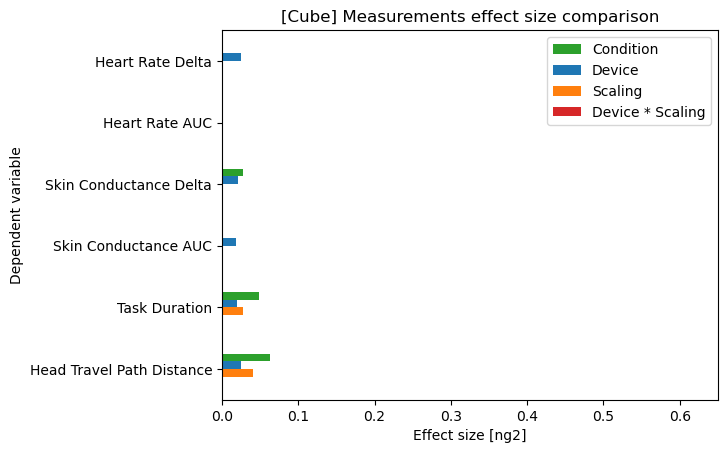

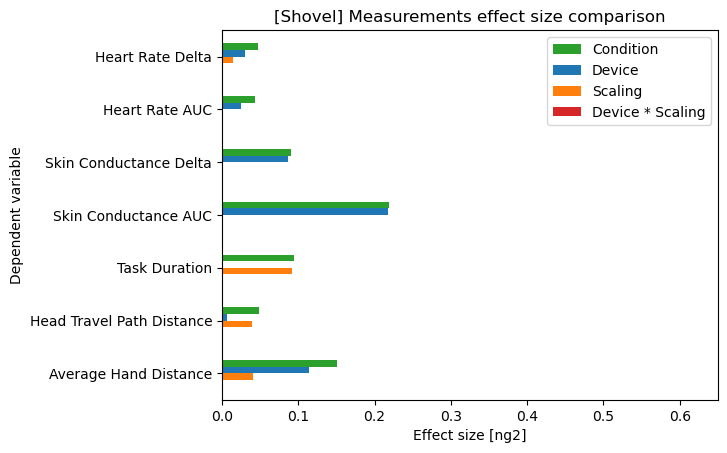

In [110]:
show_eff_size_comparison('Measurements')

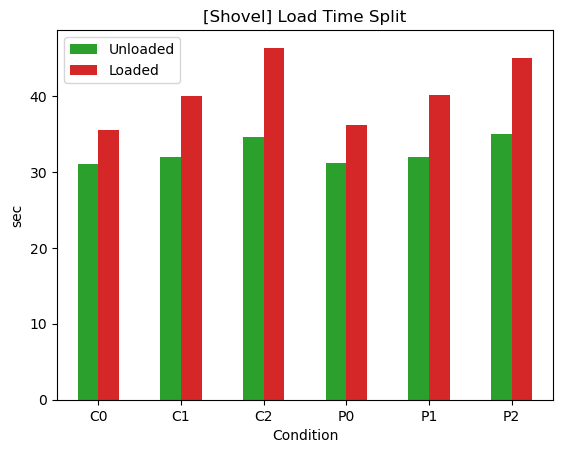

In [111]:
def single_load_time_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    loaded_time = 0
    unloaded_time = 0

    for i in range(20):
        single = df[(df["collision_or_load_count"] == i+1)]

        unloaded = single[(single["shovel_loaded_state"] == False)]
        unloaded_time += unloaded[unity_unix_key].max() - unloaded[unity_unix_key].min()

        loaded = single[(single["shovel_loaded_state"] == True)]
        loaded_time += loaded[unity_unix_key].max() - loaded[unity_unix_key].min()
    
    return [unloaded_time / 1_000, loaded_time / 1_000]

def agg_load_time_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    splits = list(map(lambda x: single_load_time_split(x), participants))
    
    unloaded_times = list(map(lambda x: x[0], splits))
    loaded_times = list(map(lambda x: x[1], splits))
    
    return [np.mean(unloaded_times), np.mean(loaded_times)]

condition_splits = list(map(lambda x: agg_load_time_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["Unloaded", "Loaded"], index = conditions)

df.plot(kind='bar', color=["tab:green", "tab:red"])

plt.title("[Shovel] Load Time Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

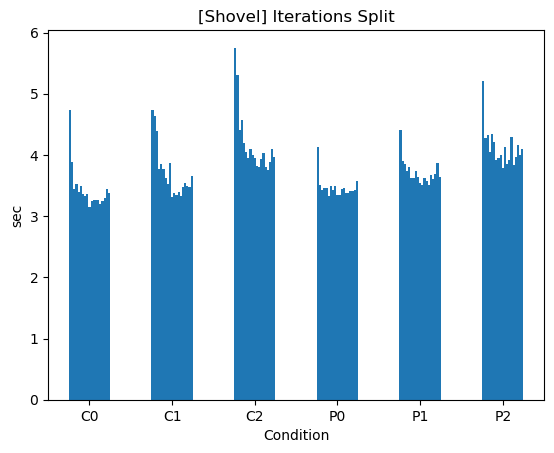

In [112]:
n_iterations = range(19)

def single_iteration_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    iteration_times = []

    for i in n_iterations:
        iteration = df[(df["collision_or_load_count"] == i+1)]
        time = (iteration[unity_unix_key].max() - iteration[unity_unix_key].min() ) / 1_000
        iteration_times.append(time)
    
    return iteration_times

def agg_iteration_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    participant_splits = list(map(lambda x: single_iteration_split(x), participants))
    n_participants = len(participants)

    splits = []

    for i in n_iterations:
        splits.append([])
        for j in range(n_participants):
            splits[i].append(participant_splits[j][i])

    split_means = list(map(lambda x: np.mean(x), splits))
    
    return split_means

condition_splits = list(map(lambda x: agg_iteration_split(data, x), conditions))

columns = list(map(lambda x: str(x+1), n_iterations))

df = pd.DataFrame(condition_splits, columns=columns, index = conditions)

df.plot(kind='bar', color = "tab:blue", legend=False)

plt.title("[Shovel] Iterations Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

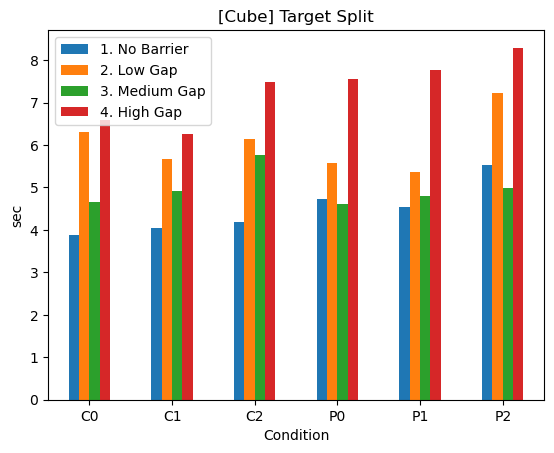

In [113]:
def single_target_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_time = first[unified_unix_key].max() - first[unified_unix_key].min()
    second_time = second[unified_unix_key].max() - second[unified_unix_key].min()
    third_time = third[unified_unix_key].max() - third[unified_unix_key].min()
    fourth_time = fourth[unified_unix_key].max() - fourth[unified_unix_key].min()

    return [first_time / 1_000, second_time / 1_000, third_time / 1_000, fourth_time / 1_000]

def agg_target_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_target_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.mean(first), np.mean(second), np.mean(third), np.mean(fourth)]

condition_splits = list(map(lambda x: agg_target_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Target Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()